다양한 graph 패턴
- Router : 어떤 것인지 분류 후 각각에 대한 처리로 분류
- Parallel Calling + Map Reduce : 각자 실행후 값을 합치는 방식
- Evaluator-Optimizer 방식 : 평가 후 다시할지 등을 반복하면서 수행

## 환경설정 및 Jupyter 설치
### 가상환경 세팅
```bash
conda create --name env-langgraph-fc python=3.10 -y
```
<br/>

### 세팅 확인
가상환경 디렉터리 확인
```bash
ls -al ~/miniforge3/envs/env-langgraph-fc 
```
<br/>

가상환경 활성화
```bash
conda activate env-langgraph-fc
```
<br/>

가상환경을 끌때는 다음과 같이 한다.
```bash
conda deactivate
```
<br/>

### 의존성 설정
먼저 jupyter 설치
```bash
# pip 대신 mamba를 사용하면 패키지 설치 속도가 훨씬 빠릅니다.
mamba install -c conda-forge jupyter notebook ipykernel -y
```
<br/>

다음 의존성 설치
```bash
## pip 를 이용해 설치
!pip install langgraph langchain langchain_google_genai langchain_community

## 또는 mamba 를 이용해 설치
mamba install langgraph langchain langchain_google_genai langchain_community
```
<br/>

keyring 라이브러리 설치
```bash
## pip 을 이용해 설치
pip install keyring

## 또는 mamba 를 이용해 keyring 설치
mamba install keyring
```
<br/>

## keyring import (api key 설정)
- (1) 미리 터미널에 입력해둔다.
- (2) python 코드 내에서 사용한다.

```bash
## bash 쉘 에서 다음 내용을 입력
## 형식 keyring set {{서비스명}} {{계정명}}

## e.g.
keyring set gemini-api-key---alpha300uk alpha300uk  
Password for 'alpha300uk' in 'gemini-api-key---alpha300uk':
```

In [17]:
import keyring
gemini_service_name = "gemini-api-key---alpha300uk"
gemini_username = "alpha300uk"
gemini_api_token = keyring.get_password(gemini_service_name, gemini_username)

tavily_service_name = "tavily-api-key---alpha300uk"
tavily_username = "alpha300uk"
taviliy_api_token = keyring.get_password(tavily_service_name, tavily_username)

## 의존성 설치 (혹시 설치 안했을 경우를 위해 추가한 섹션)

In [3]:
! pip install langgraph langchain langchain_google_genai langchain_community

## llm, ratelimiter 선언

In [ ]:
## llm, ratelimiter 선언
import os
os.environ['GOOGLE_API_KEY'] = gemini_api_token

from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

# Gemini API는 분당 10개 요청으로 제한
# 즉, 초당 약 0.167개 요청 (10/60)
rate_limiter = InMemoryRateLimiter(
    # requests_per_second=0.167,  # 분당 10개 요청
    requests_per_second=1,  # 초당 최대 1개, 분당 최대 60개 요청
    check_every_n_seconds=0.1,  # 100ms마다 체크
    max_bucket_size=10,  # 최대 버스트 크기
)

# rate limiter를 LLM에 적용
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    rate_limiter=rate_limiter,
    # temperature
    # max_tokens

    thinking_budget = 500  # 추론(Reasoning) 토큰 길이 제한
)

## (1) router
라우터는 State의 값을 참고하여, 목적에 따라 서로 다른 노드로 전달하는 방식을 의미합니다.   
주로 사용자의 입력을 분류하여 서로 다른 작업을 연결하는 의도 분류(Intent Classfication)에서 활용됩니다.

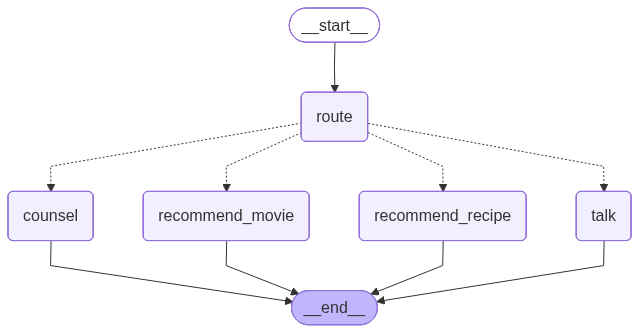

In [19]:
### 자료구조
from typing_extensions import TypedDict, Annotated, Literal, List
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages

class Recipe(BaseModel):
    name: str = Field(..., description="음식 이름")
    difficulty: str = Field(..., description="만들기의 난이도")
    origin: str = Field(..., description="원산지")
    ingredients: List[str] = Field(..., description="재료 목록")
    instructions: List[str] = Field(..., description="조리법")
    taste: List[str] = Field(..., description="맛에 대한 한 마디의 묘사!")

class Movie(BaseModel):
    name: str = Field(..., description="영화 이름")
    director: str = Field(..., description="감독명")
    actor: List[str] = Field(..., description="주연 배우: 최대 3명까지")
    recommendation: str = Field(..., description="추천하는 이유!")


class State(TypedDict):
    query: str
    classification: str
    recipe: Recipe
    movie:Movie
    advice : Literal['네!', '아니오.']
    # Literal: 범위가 특정 값으로 한정되는 경우
    answer: str


### PromptTemplates
from langchain_core.prompts import ChatPromptTemplate
import random

def recommend_recipe(state):
    prompt = ChatPromptTemplate([
    ('system','당신은 전세계의 이색적인 퓨전 조리법의 전문가입니다.'),
    ('user','''{query}''')
    ])

    recipe_chain = prompt | llm.with_structured_output(Recipe)

    return {'recipe':recipe_chain.invoke(state)}
    # query --> query

def recommend_movie(state):
    prompt = ChatPromptTemplate([
    ('system','당신은 고전 영화의 전문가입니다.'),
    ('user','''{query}''')
    ])

    movie_chain = prompt | llm.with_structured_output(Movie)

    return {'movie':movie_chain.invoke(state)}
    # query --> query


def talk(state):
    return {'answer':llm.invoke(state['query']).content}


def counsel(state):
    if random.random()>=0.5:
        return {'advice':'네!'}
    else:
        return {'advice':'아니오.'}


### route 함수들
def route(state):

    prompt = ChatPromptTemplate(
        [('system', '''당신의 역할은 사용자의 질문에 대답할 사람을 선택하는 것입니다.
1) 음식 관련 질문: 'FOOD'만 출력하세요.
2) 영화 관련 질문: 'MOVIE'만 출력하세요.
3) 고민 상담: 'COUNSEL'만 출력하세요.
4) 그 외의 대화: 'TALK'만 출력하세요.
             '''),
             ('user','User Query: {query}')
        ]
    )
    # Structured_Output으로 만들 수도 있습니다!

    route_chain = prompt | llm

    return {"classification": route_chain.invoke(state).content}
    # query --> query


def route_decision(state):
    # Exact Match 대신 조금 안정적인 조건식

    if "FOOD" in state["classification"]:
        return "recommend_recipe"
    elif "MOVIE" in state["classification"]:
        return "recommend_movie"
    elif "TALK" in state["classification"]:
        return "talk"
    else:
        return "counsel"


### LangGraph 정의
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node('recommend_movie', recommend_movie)
builder.add_node('recommend_recipe', recommend_recipe)
builder.add_node('counsel', counsel)
builder.add_node('talk', talk)
builder.add_node('route', route)

builder.add_edge(START, 'route')
builder.add_conditional_edges('route', route_decision,
                              {'recommend_movie':'recommend_movie',
                               'recommend_recipe':'recommend_recipe',
                               'counsel':'counsel',
                               'talk':'talk'})

builder.add_edge('recommend_movie', END)
builder.add_edge('recommend_recipe', END)
builder.add_edge('counsel', END)
builder.add_edge('talk', END)

graph = builder.compile()
graph

In [20]:
query = '주식을 주제로 어울리는 한국영화,넷플릭스 추천해줘.'

result = graph.invoke({'query':query})
result

{'query': '주식을 주제로 어울리는 한국영화,넷플릭스 추천해줘.',
 'classification': 'MOVIE',
 'movie': Movie(name='돈', director='박누리', actor=['류준열', '유지태', '조우진'], recommendation='고전 영화 전문가는 아니지만, 주식 시장의 냉혹한 현실과 돈의 유혹을 다룬 이 영화는 현대 사회의 고전적인 욕망을 잘 보여줍니다. 신입 주식 브로커가 작전 세력과 엮이면서 벌어지는 이야기를 통해 돈을 쫓는 인간의 모습을 흥미롭게 그려내어, 현재 넷플릭스에서 시청 가능하며 고전적인 주제 의식을 현대적으로 풀어낸 작품이라 추천합니다.')}

In [21]:
query = '당근으로 만들 수 있는 다이어트 식단 추천해주세요'

result = graph.invoke({'query':query})
result

{'query': '당근으로 만들 수 있는 다이어트 식단 추천해주세요',
 'classification': 'FOOD',
 'recipe': Recipe(name='당근 라따뚜이 퀴노아 샐러드', difficulty='쉬움', origin='퓨전 (프랑스-중동)', ingredients=['당근 2개', '퀴노아 1컵', '물 2컵', '가지 1/2개', '애호박 1/2개', '빨간 파프리카 1/2개', '노란 파프리카 1/2개', '양파 1/2개', '다진 마늘 2쪽', '올리브 오일 3큰술', '레몬즙 2큰술', '신선한 파슬리 또는 고수 다진 것 2큰술', '소금 약간', '후추 약간', '병아리콩 (통조림) 1/2컵 (선택 사항)'], instructions=['퀴노아는 깨끗이 씻어 물 2컵과 함께 냄비에 넣고 끓으면 약불로 줄여 물이 모두 흡수될 때까지 15분간 익힌 후 5분간 뜸 들인다.', '당근, 가지, 애호박, 파프리카, 양파는 모두 1.5cm 크기의 주사위 모양으로 깍둑썰기 한다.', '큰 팬에 올리브 오일 2큰술을 두르고 중간 불로 달군 후 양파와 다진 마늘을 넣고 2분간 볶는다.', '깍둑썰기한 당근, 가지, 애호박, 파프리카를 팬에 넣고 소금, 후추로 간하여 채소가 부드러워질 때까지 10-15분간 볶는다.', '익힌 퀴노아와 볶은 채소를 큰 볼에 담고, 남은 올리브 오일 1큰술, 레몬즙, 다진 파슬리(또는 고수)를 넣고 잘 섞는다.', '선택 사항인 병아리콩을 넣고 한 번 더 가볍게 섞어준다. 맛을 보고 필요하면 소금, 후추를 추가한다.'], taste=['신선한 채소의 달콤함과 퀴노아의 고소함이 어우러진 산뜻하고 건강한 맛!', '지중해의 햇살 같은 상큼함과 씹는 맛이 살아있는 다이어트 별미!'])}

In [22]:
query = 'MoE 구조에 대해 5문장으로 설명해주세요.'

result = graph.invoke({'query':query})
result

{'query': 'MoE 구조에 대해 5문장으로 설명해주세요.',
 'classification': 'TALK',
 'answer': "MoE(Mixture of Experts) 구조는 여러 개의 작은 신경망인 '전문가(Expert)'들과 이들 중 어떤 전문가를 사용할지 결정하는 '게이트(Gate)' 네트워크로 구성됩니다. 입력 데이터가 들어오면 게이트 네트워크는 이를 분석하여 가장 적합하다고 판단되는 소수의 전문가를 선택합니다. 선택된 전문가들만이 해당 입력에 대한 연산을 수행하며, 각 전문가는 특정 유형의 데이터나 작업에 특화될 수 있습니다. 이 방식은 전체 모델의 파라미터 수는 매우 크지만, 실제 연산 시에는 일부 전문가만 활성화되어 효율성을 높입니다. 결과적으로 MoE는 적은 연산량으로도 거대한 모델 용량과 높은 성능을 달성하여 복잡한 태스크에 효과적입니다."}

각각이 Movie, Receipe, Talk 타입으로 생성된 것을 확인할 수 있다.

## (2) Map-Reduce   
router 에서는 분류 후에 LLM을 한번 호출했다.
그런데 각자 실행하고 합치는 구조도 만들 수 있다. 

이번 문제에서는 대표적인 작업인 리포트 작성 구조를 확인해본다.
이 방식은 최초의 LLM이 주제에 대한 섹션을 먼저 구성하고, 섹션별 리포트를 각각의 LLM이 작성하는 방식이다.

State: 그래프에서 사용할 LLM
SubState : WriterLLM이 사용할 State
orchestrator : 섹션을 생성하는 노드

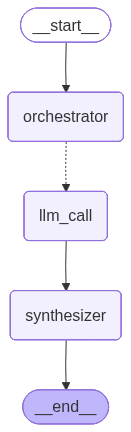

In [23]:
import operator

## 섹션 구획
# 전체 섹션의 구획: Contents (Chapter List)
# Chapter: name, outline
class Chapter(BaseModel):
    name: str = Field(description="챕터의 이름")
    outline: str = Field(description="챕터의 주요 내용, 1문장 길이로")


class Contents(BaseModel):
    contents: List[Chapter] = Field(description="전체 리포트의 섹션 구성")


planner = llm.with_structured_output(Contents)


# reducer 구조: operator.add
# 단순 + 연산 구조 (리스트의 + 연산이므로 append)

### state 정의
class State(TypedDict):
    topic: str
    contents: list[Chapter]
    completed_sections: Annotated[list, operator.add]
    final_report: str


# 섹션 Writer가 사용할 State
class SubState(TypedDict):
    chapter: Chapter
    completed_sections: Annotated[list, operator.add]


from langchain_core.messages import HumanMessage, AIMessage, SystemMessage


## 섹션을 생성하는 노드
def orchestrator(state: State):

    prompt = ChatPromptTemplate([
        ('system', "주제에 대한 전문가 수준의 깊이 있는 한국어 보고서를 쓰려고 합니다. 보고서의 섹션 구성과, 각 섹션의 간단한 설명을 작성해 주세요."),
        ('user', "주제: {topic}")
    ])
    chain = prompt | planner

    # chain 결과물: Contents (contents: List[Chapter])

    return {"contents": chain.invoke(state).contents}
    # state: topic --> topic
    # Return: List[Chapter]


## 섹션 별 내용을 처리하는 노드 들 구성
def llm_call(state: SubState):
    # SubState :  chapter, completed_sections 2개 property

    chapter = state['chapter']

    prompt = ChatPromptTemplate([
        ('system',"아래 섹션에 대한 상세한 한국어 보고서를 작성하세요." ),
        ('user', "섹션 이름과 주제는 다음과 같습니다: {name} --> {outline}")
    ])

    chain = prompt | llm

    return {"completed_sections": [chain.invoke({'name':chapter.name, 'outline':chapter.outline}).content]}
    # 리스트로 Wrap하는 이유 중요(Reduce Operator 합치기 위해서)


# 생성된 섹션별 결과들을 결합
def synthesizer(state: State):

    completed_sections = state["completed_sections"]

    completed_report_sections = "\n\n---\n\n".join(completed_sections)
    # join: 전체 리스트 스트링으로 결합하기

    return {"final_report": completed_report_sections}


### 가장 중요한 부분 
### langgraph 의 Send 를 이용하면 리스트의 원소 개수 만큼 서브모듈을 호출할 수 있다.
from langgraph.types import Send

def assign_workers(state: State):
    # Send: 노드를 호출하며, 값을 전달해 준다
    # state['contents']의 개수를 기본적으로 알 수 없는데,
    # 이를 통해 개수만큼 llm_call을 생성하여 호출할 수 있음

    return [Send("llm_call", {"chapter": s}) for s in state["contents"]]


### Graph 구성
builder = StateGraph(State)

builder.add_node("orchestrator", orchestrator) # 구획 짜고
builder.add_node("llm_call", llm_call) # 섹션별 글쓰고
builder.add_node("synthesizer", synthesizer) # 합치고


builder.add_edge(START, "orchestrator")

builder.add_conditional_edges("orchestrator", assign_workers, ["llm_call"])
# assign_workers의 결과에 따라 llm_call을 호출

builder.add_edge("llm_call", "synthesizer")
# 생성된 섹션들은 synthesizer로 이동

builder.add_edge("synthesizer", END) # 끝


graph = builder.compile()
graph

In [24]:
for data in graph.stream({"topic": "GPT 1부터 최신 LLM까지의 발전과정"}, stream_mode='updates'):
    print(data)
    print('--------------')
    # 생성은 병렬적이지만 합치는 순서는 호출한 순서

{'orchestrator': {'contents': [Chapter(name='서론: LLM 발전의 시대적 배경과 중요성', outline='보고서의 목적과 범위, 그리고 거대 언어 모델(LLM)이 인공지능 분야에 미친 혁명적 영향을 제시합니다.'), Chapter(name='트랜스포머 아키텍처의 등장과 GPT-1의 탄생', outline='GPT-1 이전의 언어 모델 한계를 조명하고, 트랜스포머 아키텍처의 핵심 원리 및 GPT-1이 제시한 생성형 사전 학습(Generative Pre-training) 개념을 설명합니다.'), Chapter(name='GPT-2: 스케일업과 제로샷 학습의 가능성', outline='GPT-2의 모델 크기 확장 전략과 비지도 학습을 통한 일반화 능력 향상, 그리고 제로샷 학습의 잠재력을 분석합니다.'), Chapter(name='GPT-3: 범용 인공지능으로의 한 걸음과 프롬프트 엔지니어링의 부상', outline='GPT-3의 파격적인 스케일과 인컨텍스트 학습(In-context Learning) 능력을 통해 범용 AI의 가능성을 보여준 점, 그리고 프롬프트 엔지니어링의 중요성을 다룹니다.'), Chapter(name='GPT-3.5 및 InstructGPT: 정렬(Alignment)과 인간 피드백의 중요성', outline='인간 피드백을 활용한 강화 학습(RLHF)이 모델의 유용성과 안전성을 향상시키는 데 기여한 과정과 그 의미를 설명합니다.'), Chapter(name='GPT-4 및 최신 LLM 동향: 멀티모달리티와 추론 능력 강화', outline='GPT-4의 발전된 추론 능력, 멀티모달리티 지원, 그리고 LLaMA, Gemini 등 최신 LLM들이 지향하는 기술적 방향성을 분석합니다.'), Chapter(name='LLM 발전의 주요 기술적 혁신과 도전 과제', outline='스케일링 법칙, RLHF, MoE(Mixture of Experts) 등 핵심 기술 혁신을 조명하고, 환각(Hallucination), 

In [25]:
## Markdown 형태로 변환해서 확인

from IPython.display import Markdown
Markdown(data['synthesizer']["final_report"])

## 서론: LLM 발전의 시대적 배경과 중요성

### 1. 시대적 배경: 인공지능 기술의 비약적인 발전과 거대 언어 모델의 등장

현대 사회는 인공지능(AI) 기술이 전례 없는 속도로 발전하며 우리 삶의 모든 측면을 변화시키고 있는 혁명적인 시대를 맞이하고 있습니다. 특히 지난 몇 년간, 딥러닝(Deep Learning) 기술의 발전과 컴퓨팅 자원의 폭발적인 증가는 인공지능 분야에 새로운 지평을 열었으며, 그 중심에는 **거대 언어 모델(Large Language Model, LLM)**이 자리하고 있습니다.

LLM의 등장은 단순히 기존 인공지능 모델의 성능을 향상시킨 것을 넘어, 인간의 언어를 이해하고 생성하며 추론하는 능력이 비약적으로 발전하는 계기가 되었습니다. 과거의 AI 모델들이 특정 작업을 위해 설계된 '좁은 인공지능(Narrow AI)'의 한계를 가졌다면, LLM은 방대한 양의 텍스트 데이터를 학습하여 다양한 언어 관련 작업을 수행할 수 있는 '범용적인 능력'을 선보이며 인공지능의 가능성을 확장했습니다. 이러한 변화는 딥러닝, 특히 트랜스포머(Transformer) 아키텍처의 혁신, 대규모 데이터셋의 구축, 그리고 고성능 GPU 기반의 컴퓨팅 파워 발전이라는 세 가지 핵심 요소가 결합된 결과입니다.

### 2. LLM이 인공지능 분야에 미친 혁명적 영향

거대 언어 모델은 인공지능 분야에 다음과 같은 혁명적인 영향을 미쳤습니다.

*   **패러다임 전환:** 기존의 규칙 기반 시스템이나 통계적 모델링을 넘어, 데이터로부터 스스로 패턴을 학습하고 새로운 콘텐츠를 생성하는 '생성형 AI(Generative AI)' 시대를 열었습니다. 이는 인공지능이 단순히 분석 도구를 넘어 창조적인 역할을 수행할 수 있음을 증명했습니다.
*   **범용성과 확장성:** 하나의 모델이 번역, 요약, 질문 답변, 코드 생성, 창의적 글쓰기 등 다양한 작업을 수행할 수 있는 범용성을 제공합니다. 이는 각 작업마다 별도의 모델을 개발해야 했던 기존 방식의 비효율성을 해소하고, 인공지능 기술의 적용 범위를 무한히 확장시켰습니다.
*   **인간-컴퓨터 상호작용의 변화:** 자연어 기반의 직관적인 인터페이스를 통해 사용자들이 복잡한 기술 지식 없이도 인공지능과 소통하고 활용할 수 있게 되었습니다. 이는 인공지능의 대중화를 가속화하고, 인간과 컴퓨터의 상호작용 방식을 근본적으로 변화시키고 있습니다.
*   **새로운 산업 생태계 조성:** LLM은 챗봇, 가상 비서, 콘텐츠 생성 도구, 교육 보조 도구, 소프트웨어 개발 보조 등 수많은 신규 애플리케이션과 서비스를 탄생시켰으며, 이는 전 산업 분야에 걸쳐 혁신적인 변화와 새로운 비즈니스 기회를 창출하고 있습니다.

### 3. 보고서의 목적과 범위

본 보고서는 거대 언어 모델(LLM)의 급부상과 그로 인한 인공지능 분야의 혁명적 변화를 심층적으로 분석하는 것을 목적으로 합니다. 구체적으로, 다음과 같은 내용을 다룰 것입니다.

*   **LLM의 기술적 원리 및 발전 과정:** 트랜스포머 아키텍처를 중심으로 LLM의 핵심 기술과 주요 발전 단계를 설명합니다.
*   **주요 LLM 모델 분석:** GPT 시리즈, BERT, LLaMA 등 대표적인 LLM 모델들의 특징과 성능을 비교 분석합니다.
*   **LLM의 응용 분야 및 실제 사례:** LLM이 현재 활용되고 있는 다양한 산업 분야와 구체적인 성공 사례들을 제시합니다.
*   **LLM의 한계점 및 윤리적 고려사항:** 현재 LLM이 직면하고 있는 기술적, 사회적 문제점들을 고찰하고, 이에 대한 대응 방안을 논의합니다.
*   **LLM의 미래 전망:** 앞으로 LLM 기술이 나아갈 방향과 잠재적인 발전 가능성을 예측합니다.

이 보고서를 통해 독자들은 LLM이 인공지능 시대의 핵심 동력임을 이해하고, 이 기술이 가져올 미래 사회의 변화에 대한 통찰력을 얻을 수 있을 것입니다.

---

## 트랜스포머 아키텍처의 등장과 GPT-1의 탄생

이 섹션에서는 2010년대 후반 자연어 처리(NLP) 분야에 혁명적인 변화를 가져온 트랜스포머 아키텍처의 등장 배경과 핵심 원리를 살펴보고, 이를 기반으로 탄생한 GPT-1(Generative Pre-trained Transformer 1)이 제시한 '생성형 사전 학습(Generative Pre-training)'이라는 새로운 패러다임에 대해 상세히 설명합니다.

---

### 1. GPT-1 이전 언어 모델의 한계

GPT-1이 등장하기 전, 자연어 처리 분야를 지배했던 주요 딥러닝 모델은 **순환 신경망(RNN)**과 그 변형인 **장단기 기억 신경망(LSTM)**, **게이트 순환 유닛(GRU)**이었습니다. 이 모델들은 시퀀스 데이터를 처리하는 데 강점을 보였지만, 다음과 같은 근본적인 한계에 직면해 있었습니다.

*   **순차적 처리의 비효율성:** RNN 계열 모델은 단어를 하나씩 순차적으로 처리하며 이전 상태를 다음 상태로 전달하는 방식으로 작동합니다. 이는 문장의 길이가 길어질수록 처리 속도가 매우 느려지며, GPU와 같은 병렬 처리 장치의 이점을 충분히 활용하기 어렵게 만들었습니다.
*   **장거리 의존성 학습의 어려움 (Vanishing/Exploding Gradients):** 문장의 앞부분에 있는 정보가 뒷부분의 의미에 중요한 영향을 미치는 '장거리 의존성(Long-Range Dependencies)'을 학습하는 데 어려움이 있었습니다. 역전파 과정에서 기울기(gradient)가 점차 소실되거나 폭발하는 문제로 인해, 모델이 멀리 떨어진 단어 간의 관계를 효과적으로 포착하기 힘들었습니다. 이는 특히 긴 텍스트에서 문맥을 정확하게 이해하고 생성하는 능력을 저해했습니다.
*   **고정된 문맥 벡터의 한계:** RNN 계열 모델은 일반적으로 이전 정보를 고정된 크기의 은닉 상태(hidden state) 벡터에 압축하여 다음 단계로 전달합니다. 이는 긴 문맥의 모든 중요한 정보를 하나의 고정된 벡터에 담는 데 한계가 있으며, 정보 손실을 야기할 수 있었습니다.
*   **병렬화의 어려움:** 순차적 처리 방식은 본질적으로 병렬 계산을 어렵게 만들어, 모델의 훈련 속도와 확장성을 제한했습니다. 이는 대규모 데이터셋을 활용한 훈련에 큰 걸림돌이었습니다.

이러한 한계들로 인해, 당시의 언어 모델들은 복잡한 문맥을 이해하고 자연스럽고 일관성 있는 긴 텍스트를 생성하는 데 어려움을 겪었으며, 특정 태스크에 특화된 모델을 처음부터 다시 훈련시켜야 하는 비효율성이 존재했습니다.

### 2. 트랜스포머 아키텍처의 핵심 원리

2017년 Google 연구팀이 발표한 논문 "Attention Is All You Need"에서 소개된 **트랜스포머(Transformer)** 아키텍처는 위에서 언급된 RNN 계열 모델의 한계를 극복하며 NLP 분야에 혁명적인 변화를 가져왔습니다. 트랜스포머의 가장 핵심적인 특징은 순환(Recurrence)이나 합성곱(Convolution) 없이 **어텐션(Attention) 메커니즘**만을 사용하여 시퀀스 데이터를 처리한다는 점입니다.

트랜스포머의 주요 원리는 다음과 같습니다.

*   **셀프 어텐션(Self-Attention) 메커니즘:**
    *   트랜스포머의 핵심은 **셀프 어텐션**입니다. 이는 문장 내의 각 단어가 문장 내의 다른 모든 단어들과 얼마나 관련이 있는지를 스스로 학습하여 가중치를 부여하는 메커니즘입니다.
    *   각 단어는 Query(질의), Key(열쇠), Value(값)라는 세 가지 벡터로 변환됩니다. 특정 단어의 Query 벡터는 문장 내의 다른 모든 단어의 Key 벡터와 내적되어 유사도를 계산하고, 이를 소프트맥스(softmax) 함수를 통해 확률 분포 형태의 어텐션 가중치로 변환합니다. 최종적으로 이 가중치들을 Value 벡터에 곱하여 합산함으로써 해당 단어의 새로운 표현(representation)을 얻습니다.
    *   이 과정을 통해 모델은 문장 내의 모든 단어 쌍 간의 관계를 동시에 파악하고, 각 단어의 문맥적 의미를 풍부하게 인코딩할 수 있게 됩니다. 예를 들어, "The animal didn't cross the street because it was too tired."라는 문장에서 'it'이 'animal'을 가리킨다는 것을 셀프 어텐션이 학습할 수 있습니다.
*   **병렬 처리 가능성:** 셀프 어텐션은 각 단어의 표현을 계산할 때 문장 내의 모든 단어에 동시에 접근할 수 있기 때문에, RNN처럼 순차적으로 처리할 필요가 없습니다. 이는 GPU와 같은 병렬 컴퓨팅 장치를 최대한 활용하여 모델 훈련 속도를 획기적으로 향상시켰습니다.
*   **위치 인코딩(Positional Encoding):**
    *   트랜스포머는 순환 구조가 없기 때문에 단어의 순서 정보를 자체적으로 학습할 수 없습니다. 이를 보완하기 위해 각 단어의 임베딩 벡터에 단어의 상대적 또는 절대적 위치 정보를 담은 **위치 인코딩** 벡터를 더해줍니다.
    *   이 인코딩은 사인(sine) 및 코사인(cosine) 함수를 사용하여 고유한 위치 정보를 제공하며, 모델이 문장 내 단어들의 순서와 거리를 이해할 수 있도록 돕습니다.
*   **인코더-디코더 구조:**
    *   원래 트랜스포머는 입력 시퀀스를 인코딩하는 **인코더 스택**과 인코딩된 정보를 바탕으로 출력 시퀀스를 디코딩하는 **디코더 스택**으로 구성됩니다. 각 스택은 여러 개의 동일한 레이어로 이루어져 있으며, 각 레이어는 멀티헤드 셀프 어텐션(Multi-Head Self-Attention)과 피드포워드 신경망(Feed-Forward Network)을 포함합니다.
    *   멀티헤드 어텐션은 여러 개의 어텐션 메커니즘을 병렬로 수행하여 다양한 관점에서 관계를 파악하고 이를 결합하여 더 풍부한 정보를 얻습니다.

트랜스포머는 이러한 혁신적인 구조를 통해 장거리 의존성 문제를 효과적으로 해결하고, 병렬 처리를 통해 대규모 데이터셋 학습을 가능하게 함으로써 대규모 언어 모델의 시대를 열었습니다.

### 3. GPT-1의 탄생과 생성형 사전 학습(Generative Pre-training) 개념

트랜스포머 아키텍처의 등장 이후, OpenAI는 2018년 "Improving Language Understanding by Generative Pre-training" 논문을 통해 **GPT-1(Generative Pre-trained Transformer 1)**을 발표하며 NLP 분야에 새로운 패러다임을 제시했습니다. GPT-1은 트랜스포머의 디코더(Decoder) 부분만을 활용한 모델로, **생성형 사전 학습(Generative Pre-training)**이라는 개념을 도입하여 NLP 모델 개발 방식의 전환점을 마련했습니다.

**생성형 사전 학습(Generative Pre-training) 개념:**

GPT-1 이전의 NLP 모델들은 대부분 특정 태스크(예: 감성 분석, 개체명 인식, 기계 번역)를 위해 처음부터 대량의 **레이블링된 데이터(labeled data)**를 사용하여 훈련되었습니다. 이는 데이터 수집 및 레이블링에 막대한 비용과 시간이 소요되며, 새로운 태스크가 등장할 때마다 이 과정을 반복해야 하는 비효율성을 가졌습니다.

GPT-1이 제시한 생성형 사전 학습은 이러한 한계를 극복하기 위한 2단계 접근 방식입니다.

1.  **사전 학습 (Pre-training):**
    *   모델은 레이블이 없는(unlabeled) 방대한 양의 텍스트 데이터(예: 웹 문서, 책)를 사용하여 '다음 단어 예측(next word prediction)'과 같은 **생성형 태스크**를 통해 사전 훈련됩니다.
    *   GPT-1은 트랜스포머의 디코더 구조를 활용하여 이전 단어들을 기반으로 다음 단어를 예측하도록 학습합니다. 이 과정에서 모델은 언어의 통계적 패턴, 문법, 그리고 단어 간의 복잡한 문맥적 관계를 자동으로 학습하여 일반적인 언어 이해 능력을 습득합니다.
    *   이 단계는 마치 어린아이가 수많은 책을 읽으며 세상의 지식과 언어의 규칙을 배우는 과정과 유사합니다. 모델은 특정 태스크에 얽매이지 않고 일반적인 언어 표현을 학습합니다.
2.  **미세 조정 (Fine-tuning):**
    *   사전 학습을 통해 언어에 대한 일반적인 이해 능력을 갖춘 모델은, 이제 특정 다운스트림 태스크(예: 질의응답, 요약, 문장 분류)를 수행하기 위해 상대적으로 적은 양의 **레이블링된 데이터**를 사용하여 추가적으로 훈련됩니다.
    *   이 단계에서는 사전 학습된 모델의 가중치를 초기값으로 사용하여, 특정 태스크에 최적화되도록 모델을 '미세 조정'합니다.
    *   사전 학습된 모델은 이미 풍부한 언어 지식을 가지고 있기 때문에, 미세 조정 단계에서는 적은 양의 데이터로도 빠르게 특정 태스크에 적응하고 높은 성능을 달성할 수 있습니다. 이는 마치 특정 분야의 전문가가 이미 가지고 있는 일반 지식을 바탕으로 새로운 프로젝트에 빠르게 적응하는 것과 같습니다.

**GPT-1의 의의:**

GPT-1은 트랜스포머 아키텍처의 강력한 표현 능력과 생성형 사전 학습이라는 새로운 패러다임을 결합하여, NLP 분야에 다음과 같은 중요한 변화를 가져왔습니다.

*   **전이 학습(Transfer Learning)의 시대 개막:** 대규모 비지도 학습을 통해 얻은 언어 지식을 다양한 하위 태스크에 전이하여 활용하는 전이 학습의 효과를 입증했습니다. 이는 특정 태스크별로 모델을 처음부터 훈련시킬 필요 없이, 범용적인 언어 모델을 구축하고 이를 재활용할 수 있게 했습니다.
*   **레이블링 데이터 의존도 감소:** 레이블링된 데이터의 부족 문제를 완화하고, 적은 양의 레이블 데이터로도 높은 성능을 달성할 수 있는 길을 열었습니다.
*   **성능 향상:** 다양한 NLP 벤치마크 태스크에서 당시 최고 수준의 성능을 달성하며, 언어 모델의 잠재력을 보여주었습니다.

GPT-1은 이후 BERT와 GPT-2, GPT-3 등 수많은 대규모 언어 모델(LLM)의 기반이 되는 중요한 이정표가 되었으며, 현재 우리가 목격하는 생성형 AI 시대의 서막을 열었습니다.

---

## GPT-2: 스케일업과 제로샷 학습의 가능성

### 서론
GPT-2(Generative Pre-trained Transformer 2)는 2019년 OpenAI가 발표한 대규모 언어 모델로, 이전 모델인 GPT의 아키텍처를 계승하면서도 모델 크기와 학습 데이터셋을 대폭 확장하여 놀라운 성능 향상을 보여주었습니다. 이 섹션에서는 GPT-2가 채택한 모델 크기 확장 전략, 방대한 비지도 학습을 통한 일반화 능력 향상, 그리고 이를 통해 가능해진 제로샷(Zero-shot) 학습의 잠재력을 심층적으로 분석합니다.

### 1. GPT-2의 모델 크기 확장 전략

GPT-2의 핵심적인 성공 요인 중 하나는 '스케일업(Scale-up)' 전략입니다. OpenAI는 모델의 파라미터(매개변수) 수를 늘리고 학습 데이터의 양과 질을 향상시키는 것이 언어 모델의 성능을 비약적으로 개선할 수 있다는 가설을 세웠고, 이를 GPT-2를 통해 입증했습니다.

*   **파라미터 수의 증가:**
    *   GPT-1이 약 1.17억 개의 파라미터를 가졌던 반면, GPT-2는 가장 큰 모델에서 **15억 개**의 파라미터를 가졌습니다. 이는 약 13배에 달하는 증가입니다.
    *   트랜스포머(Transformer) 아키텍처의 레이어 수, 헤드 수, 임베딩 차원 등을 확장하여 모델의 '용량'을 늘렸습니다. 이는 모델이 더 복잡한 패턴과 정보를 학습하고 저장할 수 있도록 합니다.
*   **학습 데이터셋의 확장 및 품질 향상:**
    *   GPT-2는 **WebText**라는 독자적인 데이터셋을 구축하여 학습했습니다. WebText는 Reddit에서 최소 3개의 '업보트(upvote)'를 받은 웹페이지의 아웃바운드 링크를 통해 수집된 텍스트로 구성됩니다.
    *   이 데이터셋은 약 800만 개의 문서와 40GB의 텍스트로 이루어져 있으며, 기존의 일반적인 텍스트 코퍼스(예: Wikipedia, BookCorpus)보다 훨씬 방대하고 다양한 주제와 스타일의 텍스트를 포함합니다.
    *   품질 높은 웹 데이터를 사용함으로써, 모델은 보다 자연스럽고 실제적인 언어 사용 패턴을 학습할 수 있었습니다.
*   **스케일링 법칙의 발견:**
    *   GPT-2의 스케일업 전략은 단순히 모델을 크게 만드는 것을 넘어, 모델 크기, 데이터셋 크기, 학습 시간 등과 모델 성능 사이에 일정한 '스케일링 법칙(Scaling Laws)'이 존재함을 시사했습니다. 즉, 특정 조건 하에서 모델의 규모를 키우면 성능이 예측 가능하게 향상된다는 것입니다. 이러한 발견은 이후 GPT-3를 비롯한 대규모 언어 모델 연구의 중요한 기반이 되었습니다.

### 2. 비지도 학습을 통한 일반화 능력 향상

GPT-2는 방대한 텍스트 데이터에 대한 **비지도 사전 학습(Unsupervised Pre-training)**을 통해 뛰어난 일반화 능력을 획득했습니다. 이는 모델이 특정 태스크에 대한 명시적인 레이블링된 데이터 없이도 다양한 언어 태스크를 수행할 수 있게 만드는 핵심 메커니즘입니다.

*   **학습 방식:**
    *   GPT-2는 "다음 단어 예측(next-word prediction)"이라는 단순한 비지도 학습 목표를 사용합니다. 즉, 주어진 텍스트 시퀀스 다음에 올 단어를 예측하도록 학습합니다.
    *   이러한 학습 방식은 모델이 텍스트 내의 문법적 구조, 의미론적 관계, 세계 지식, 상식 등 언어의 깊은 패턴과 맥락을 암묵적으로 학습하도록 강제합니다.
    *   방대한 WebText 데이터셋에 걸쳐 이 작업을 수행함으로써, 모델은 광범위한 주제와 스타일에 대한 이해를 구축하게 됩니다.
*   **일반화 능력의 원천:**
    *   비지도 학습은 모델이 특정 태스크에 과적합(overfit)되지 않고, 학습 데이터에 내재된 일반적인 언어 규칙과 지식을 습득하게 합니다.
    *   모델은 텍스트 생성, 요약, 번역, 질의응답 등 다양한 하위 태스크에 필요한 기초적인 언어 능력을 사전 학습 단계에서 이미 갖추게 됩니다.
    *   이는 마치 인간이 수많은 책과 글을 읽으며 자연스럽게 언어 능력을 키우는 것과 유사합니다. 특정 시험을 위해 공부하는 것이 아니라, 언어 자체에 대한 이해를 높이는 과정입니다.

### 3. 제로샷 학습의 잠재력

GPT-2의 가장 혁신적인 특징 중 하나는 **제로샷 학습(Zero-shot Learning)** 능력의 가능성을 보여주었다는 점입니다. 제로샷 학습은 모델이 특정 태스크에 대한 단 한 번의 예시나 명시적인 미세 조정(fine-tuning) 없이도 해당 태스크를 수행할 수 있음을 의미합니다.

*   **제로샷 학습의 작동 방식:**
    *   GPT-2는 사전 학습 과정에서 다양한 언어 태스크의 암묵적인 패턴을 학습했습니다. 예를 들어, 번역 태스크는 "영어를 한국어로 번역하세요: [영어 문장]"과 같은 패턴으로 나타날 수 있고, 요약 태스크는 "[긴 문서] 요약:"과 같은 패턴으로 나타날 수 있습니다.
    *   모델은 이러한 패턴을 프롬프트(prompt)로 인식하고, 마치 해당 태스크를 수행하도록 명시적으로 지시받은 것처럼 응답을 생성합니다.
    *   즉, 모델은 프롬프트의 지시사항을 이해하고, 그에 맞는 적절한 다음 단어를 예측하는 방식으로 태스크를 수행합니다.
*   **GPT-2가 보여준 제로샷 능력:**
    *   **텍스트 생성:** 주어진 프롬프트에 따라 일관성 있고 맥락에 맞는 텍스트를 생성합니다.
    *   **질의응답:** 질문에 대한 답변을 생성합니다.
    *   **요약:** 긴 텍스트를 짧게 요약합니다.
    *   **번역:** 한 언어에서 다른 언어로 번역을 시도합니다. (초기 단계에서는 제한적이었지만 가능성을 보여줌)
    *   **독해:** 주어진 지문과 질문에 기반하여 답변을 추출합니다.
*   **잠재력과 한계:**
    *   GPT-2는 이러한 제로샷 태스크에서 기존의 특정 태스크용 모델에 필적하거나 능가하는 성능을 보여주며 큰 충격을 주었습니다. 이는 특정 태스크마다 별도의 모델을 학습시키거나 대량의 레이블링된 데이터를 준비할 필요 없이, 단일 모델로 다양한 응용이 가능하다는 혁명적인 가능성을 제시했습니다.
    *   물론, 초기 GPT-2의 제로샷 능력은 완벽하지 않았으며, 특히 복잡하거나 전문적인 태스크에서는 여전히 한계를 보였습니다. 하지만, 이 모델이 열어젖힌 제로샷 학습의 문은 이후 GPT-3, GPT-4와 같은 후속 모델들이 더욱 강력한 범용 인공지능으로 발전하는 데 결정적인 이정표가 되었습니다.

### 결론
GPT-2는 모델 크기 확장 전략과 방대한 비지도 학습을 통해 언어 모델의 일반화 능력을 극대화하고, 제로샷 학습이라는 혁신적인 가능성을 제시했습니다. 이는 특정 태스크에 특화된 모델 개발 패러다임에서 벗어나, 범용적인 언어 이해 및 생성 능력을 갖춘 대규모 모델의 시대를 열었으며, 인공지능 연구 및 응용 분야에 지대한 영향을 미쳤습니다. GPT-2가 보여준 스케일링 법칙과 제로샷 능력은 현재 우리가 경험하고 있는 거대 언어 모델(LLM)의 발전의 초석이 되었습니다.

---

## GPT-3: 범용 인공지능으로의 한 걸음과 프롬프트 엔지니어링의 부상

---

### 1. 서론: 인공지능 패러다임의 전환점, GPT-3

2020년 OpenAI가 발표한 GPT-3(Generative Pre-trained Transformer 3)는 인공지능 분야에 혁명적인 변화를 가져왔습니다. 이전의 AI 모델들이 특정 작업에 특화된 경향이 강했다면, GPT-3는 그 파격적인 스케일과 이를 통해 발현된 '인컨텍스트 학습(In-context Learning)' 능력으로 범용 인공지능(Artificial General Intelligence, AGI)의 가능성을 엿보게 했습니다. 이는 단순히 성능의 향상을 넘어, AI와 상호작용하는 방식 자체를 변화시켰으며, '프롬프트 엔지니어링(Prompt Engineering)'이라는 새로운 분야의 부상을 촉발했습니다. 본 보고서는 GPT-3가 보여준 범용 AI로의 잠재력과 함께, 이 강력한 모델의 성능을 최대한 끌어내기 위한 핵심 기술인 프롬프트 엔지니어링의 중요성에 대해 심층적으로 다룹니다.

### 2. GPT-3의 파격적인 스케일과 범용 AI로의 가능성

#### 2.1. 전례 없는 규모의 모델

GPT-3의 가장 두드러진 특징은 전례 없는 규모입니다. 1,750억 개의 파라미터(매개변수)를 가진 이 모델은 이전 버전인 GPT-2(15억 개)는 물론, 당시 존재했던 다른 어떤 언어 모델보다 압도적으로 거대했습니다. 이러한 거대한 스케일은 인터넷상의 방대한 텍스트 데이터(Common Crawl, WebText, Books1, Books2, Wikipedia 등)를 학습하는 과정에서 언어의 복잡한 패턴, 문법, 상식, 심지어는 특정 도메인의 전문 지식까지 흡수할 수 있게 했습니다.

#### 2.2. 인컨텍스트 학습(In-context Learning) 능력의 발현

GPT-3의 거대한 스케일은 단순히 학습된 지식의 양을 늘리는 것을 넘어, 새로운 능력의 발현으로 이어졌는데, 그 핵심이 바로 '인컨텍스트 학습'입니다. 기존의 딥러닝 모델들은 새로운 작업을 수행하려면 해당 작업에 특화된 대량의 데이터로 모델의 파라미터를 미세 조정(fine-tuning)해야 했습니다. 하지만 GPT-3는 이러한 미세 조정 과정 없이, 입력(프롬프트)에 몇 가지 예시를 제공하는 것만으로도 새로운 작업을 이해하고 수행할 수 있는 능력을 보여주었습니다.

*   **제로샷 학습(Zero-shot Learning):** 아무런 예시 없이 지시만으로 작업을 수행합니다. (예: "다음 문장을 프랑스어로 번역하시오: 'Hello world.'")
*   **원샷 학습(One-shot Learning):** 단 하나의 예시를 통해 작업을 학습합니다. (예: "다음은 영어 단어와 그 정의이다: 'Apple: A common, edible fruit.' 이제 'Banana'의 정의를 작성하시오.")
*   **퓨샷 학습(Few-shot Learning):** 몇 개의 예시를 통해 작업을 학습합니다. 이는 GPT-3의 인컨텍스트 학습 능력을 가장 잘 보여주는 방식입니다.

이러한 인컨텍스트 학습 능력은 GPT-3가 특정 목적을 위해 설계되지 않았음에도 불구하고, 질문 응답, 요약, 번역, 코드 생성, 창의적인 글쓰기 등 다양한 언어 관련 작업을 상당한 수준으로 수행할 수 있음을 의미합니다. 이는 마치 인간이 새로운 상황에 직면했을 때 몇 가지 설명을 듣거나 예시를 보는 것만으로도 빠르게 적응하고 학습하는 방식과 유사하여, 범용 인공지능(AGI)의 핵심적인 특성인 '다재다능함(versatility)'과 '일반화 능력(generalization ability)'에 한 걸음 다가선 것으로 평가받습니다.

#### 2.3. 범용 AI로의 가능성과 한계

GPT-3는 특정 작업에 특화된 AI의 한계를 넘어, 다양한 작업을 유연하게 처리할 수 있는 잠재력을 보여줌으로써 AGI 연구에 새로운 활력을 불어넣었습니다. 이는 AI가 더 이상 '도구'가 아닌, '협력자'로서 기능할 수 있는 미래를 암시합니다. 그러나 GPT-3 역시 진정한 AGI는 아닙니다. 여전히 깊은 추론 능력, 상식의 부족, 사실 왜곡(hallucination) 문제 등 여러 한계를 가지고 있습니다. 하지만 그 스케일과 인컨텍스트 학습 능력은 AGI로 나아가는 경로에 대한 중요한 통찰력을 제공했으며, 후속 모델 개발에 지대한 영향을 미쳤습니다.

### 3. 프롬프트 엔지니어링의 부상과 중요성

GPT-3와 같은 대규모 언어 모델(LLM)의 등장과 함께, 이 모델들을 효과적으로 활용하기 위한 새로운 기술인 '프롬프트 엔지니어링'이 핵심적인 역량으로 부상했습니다.

#### 3.1. 프롬프트 엔지니어링이란 무엇인가?

프롬프트 엔지니어링은 대규모 언어 모델(LLM)의 원하는 응답을 얻기 위해 입력 프롬프트(prompt)를 설계, 최적화하는 과정을 의미합니다. 모델의 파라미터를 직접 수정하는 대신, 모델에게 주어지는 지시사항, 질문, 예시 등을 신중하게 구성하여 모델의 행동과 출력을 제어하는 기술입니다. 이는 마치 숙련된 조련사가 적절한 지시를 통해 동물에게 원하는 행동을 이끌어내듯이, AI 모델에게 올바른 '맥락'과 '방향'을 제시하는 과정이라 할 수 있습니다.

#### 3.2. 프롬프트 엔지니어링이 중요한 이유

1.  **모델 잠재력의 해제:** GPT-3와 같은 LLM은 방대한 지식과 능력을 내포하고 있지만, 이 잠재력을 끌어내기 위해서는 명확하고 효과적인 프롬프트가 필수적입니다. 부적절한 프롬프트는 모호하거나, 부정확하거나, 심지어는 유해한 결과를 초래할 수 있습니다.
2.  **인컨텍스트 학습의 극대화:** 프롬프트 엔지니어링은 GPT-3의 핵심 능력인 인컨텍스트 학습을 가장 효과적으로 활용하는 방법입니다. 퓨샷(Few-shot) 학습을 위한 적절한 예시를 프롬프트 내에 포함함으로써, 모델이 새로운 작업을 빠르게 이해하고 높은 정확도로 수행하도록 유도할 수 있습니다.
3.  **다양한 활용성 확장:** 잘 설계된 프롬프트는 하나의 모델로도 번역, 요약, 코드 생성, 아이디어 브레인스토밍, 감성 분석 등 매우 다양한 작업을 수행할 수 있게 합니다. 이는 각 작업마다 별도의 모델을 훈련할 필요 없이, 단일 모델의 활용 범위를 혁신적으로 넓힙니다.
4.  **사용자 경험 개선:** 개발자나 일반 사용자 모두에게, 원하는 결과를 얻기 위한 직관적이고 효율적인 상호작용 방식을 제공합니다. 복잡한 코딩이나 모델 훈련 지식 없이도 AI의 강력한 기능을 활용할 수 있게 해줍니다.
5.  **새로운 직업군 및 연구 분야:** 프롬프트 엔지니어링은 단순한 사용 기술을 넘어, 모델의 특성을 이해하고 최적의 상호작용 방식을 탐구하는 새로운 학문 및 전문 분야로 자리 잡고 있습니다.

#### 3.3. 프롬프트 엔지니어링의 기법 (예시)

*   **명확하고 구체적인 지시:** 모델이 수행해야 할 작업, 출력 형식, 제약 조건 등을 명확하게 제시합니다.
*   **역할 부여:** 모델에게 특정 역할(예: "당신은 전문 번역가입니다", "당신은 마케팅 전문가입니다")을 부여하여 그 역할에 맞는 응답을 유도합니다.
*   **예시 제공 (Few-shot Prompting):** 작업에 대한 몇 가지 입력-출력 예시를 제공하여 모델이 원하는 패턴을 학습하도록 돕습니다.
*   **사고 과정 유도 (Chain-of-Thought Prompting):** 모델에게 최종 답변을 내기 전에 단계별로 사고 과정을 보여주도록 요청하여 복잡한 추론 작업을 개선합니다.
*   **출력 형식 지정:** JSON, 마크다운, 특정 길이 제한 등 원하는 출력 형식을 명시합니다.

### 4. 결론: AI의 미래와 인간의 역할

GPT-3는 그 파격적인 스케일과 인컨텍스트 학습 능력을 통해 범용 인공지능의 문턱에 한 발짝 더 다가섰음을 보여주었습니다. 이는 AI가 더 이상 단순한 도구가 아닌, 인간의 지적 활동을 보조하고 확장하는 강력한 협력자가 될 수 있음을 시사합니다.

이러한 변화의 물결 속에서 '프롬프트 엔지니어링'은 대규모 언어 모델의 잠재력을 현실로 구현하는 핵심적인 기술로 부상했습니다. 모델 자체를 재구성하는 것이 아니라, '어떻게 질문하고 지시하느냐'에 따라 AI의 성능이 극적으로 달라지는 시대가 도래한 것입니다. 이는 AI 기술을 활용하는 데 있어 인간의 창의성, 문제 해결 능력, 그리고 언어적 섬세함이 얼마나 중요한지를 역설적으로 보여줍니다.

GPT-3 이후에도 더욱 강력한 모델들이 계속해서 등장하고 있으며, 프롬프트 엔지니어링은 이러한 모델들을 효과적으로 제어하고 활용하기 위한 필수적인 기술로 그 중요성이 더욱 커질 것입니다. AI의 발전은 기술 그 자체뿐만 아니라, 인간이 AI와 어떻게 상호작용하고 그 잠재력을 발휘하게 할 것인지에 대한 깊은 고민을 요구하며, 프롬프트 엔지니어링은 이 고민의 최전선에 서 있습니다.

---

## GPT-3.5 및 InstructGPT: 정렬(Alignment)과 인간 피드백의 중요성

### 서론

대규모 언어 모델(LLM)은 방대한 텍스트 데이터를 학습하여 놀라운 언어 이해 및 생성 능력을 보여주었습니다. 하지만 초기 모델들은 단순히 다음 단어를 예측하는 방식으로 학습되었기 때문에, 사용자의 의도와 동떨어지거나, 유해하거나, 사실과 다른 내용을 생성하는 문제점을 안고 있었습니다. 이러한 문제점을 해결하고 모델을 인간의 가치와 의도에 "정렬(Alignment)"시키는 과정에서 **인간 피드백을 활용한 강화 학습(Reinforcement Learning from Human Feedback, RLHF)**은 혁신적인 접근 방식으로 부상했으며, 특히 GPT-3.5와 InstructGPT의 개발에 결정적인 역할을 했습니다. 본 보고서는 RLHF가 모델의 유용성과 안전성을 향상시키는 데 기여한 과정과 그 의미를 상세히 설명합니다.

### 1. GPT-3.5와 InstructGPT의 등장 배경 및 도전 과제

GPT-3와 같은 초기 대규모 언어 모델은 막대한 양의 텍스트 데이터에서 패턴을 학습하여 인간과 유사한 텍스트를 생성하는 데 탁월한 능력을 보여주었습니다. 그러나 이러한 모델들은 다음과 같은 근본적인 한계를 가지고 있었습니다.

*   **유용성 부족 (Lack of Helpfulness):** 모델은 문법적으로 올바른 답변을 생성할 수 있었지만, 사용자가 실제로 원하는 정보를 제공하거나 질문의 맥락에 적절하게 반응하지 못하는 경우가 많았습니다. 예를 들어, 너무 장황하거나, 관련 없는 정보를 포함하거나, 단순히 질문을 회피하는 답변을 생성하기도 했습니다.
*   **사실성 부족 (Lack of Truthfulness):** 모델은 학습 데이터에 기반하여 그럴듯해 보이는 정보를 생성했지만, 때로는 "환각(hallucination)"이라고 불리는 현상처럼 사실과 다른 내용을 마치 진실인 양 지어내거나 잘못된 정보를 제공했습니다.
*   **안전성 문제 (Safety Concerns):** 모델은 유해하거나, 편향되거나, 혐오스러운 내용을 생성할 가능성을 내포하고 있었습니다. 학습 데이터에 포함된 편향이 모델에 반영되거나, 악의적인 프롬프트에 의해 부적절한 답변을 생성할 수 있었습니다.

이러한 문제들은 모델의 "정렬(Alignment)" 문제로 요약될 수 있습니다. 즉, 모델의 내부적인 학습 목표(다음 단어 예측)와 인간 사용자가 기대하는 유용하고 안전하며 사실적인 행동 사이의 간극을 줄이는 것이 핵심 과제였습니다.

### 2. 인간 피드백을 활용한 강화 학습 (RLHF)의 개념

RLHF는 이러한 정렬 문제를 해결하기 위해 고안된 강력한 방법론입니다. 이는 크게 세 단계로 진행됩니다.

1.  **지도 학습 기반 미세 조정 (Supervised Fine-Tuning, SFT):**
    *   먼저, 소수의 고품질 프롬프트-응답 쌍으로 구성된 데이터셋을 사용하여 사전 학습된 대규모 언어 모델을 미세 조정합니다. 이 단계는 모델이 특정 지시(instruction)를 이해하고 따르는 능력을 초기적으로 학습하도록 돕습니다. InstructGPT의 경우, "프롬프트에 따라 유용한 응답을 생성하라"는 지시를 따르도록 학습됩니다.

2.  **보상 모델 학습 (Reward Model Training):**
    *   이 단계는 RLHF의 핵심입니다. 미세 조정된 모델이 다양한 프롬프트에 대해 여러 개의 응답을 생성합니다.
    *   **인간 평가자(Human Annotators)**들은 이 응답들을 비교하고 순위를 매깁니다. 예를 들어, "이 네 가지 응답 중 가장 유용하고 안전하며 사실적인 것은 무엇인가?"와 같은 질문에 답하며 선호도를 표시합니다.
    *   이 인간 선호도 데이터를 기반으로 **보상 모델(Reward Model, RM)**을 학습시킵니다. 보상 모델은 주어진 프롬프트와 응답 쌍에 대해 "얼마나 좋은 응답인가"를 나타내는 스칼라 점수(보상)를 예측하도록 훈련된 또 다른 신경망입니다. 즉, 인간의 선호도를 모방하여 응답의 품질을 수치화하는 역할을 합니다.

3.  **강화 학습 (Reinforcement Learning):**
    *   마지막으로, 보상 모델을 사용하여 원래의 언어 모델을 강화 학습 방식으로 추가 학습시킵니다.
    *   이 단계에서는 PPO(Proximal Policy Optimization)와 같은 강화 학습 알고리즘이 주로 사용됩니다. 언어 모델은 "에이전트(agent)"가 되고, 새로운 응답을 생성하는 것이 "행동(action)"이며, 보상 모델이 예측하는 점수가 "보상(reward)"이 됩니다.
    *   언어 모델은 보상 모델로부터 높은 점수를 받을 수 있는 응답을 생성하도록 학습됩니다. 이 과정에서 초기 SFT 모델의 응답 분포에서 너무 멀리 벗어나지 않도록 페널티를 부여하는 KL(Kullback-Leibler) 발산 항을 추가하여 모델이 일관성을 유지하고, 너무 공격적으로 보상 모델을 "속이는" 것을 방지합니다.

### 3. RLHF를 통한 유용성 및 안전성 향상 과정

RLHF는 위에서 설명한 과정을 통해 모델의 유용성과 안전성을 다음과 같이 혁신적으로 향상시켰습니다.

#### 3.1. 유용성(Helpfulness) 향상

*   **사용자 의도에 대한 이해 증진:** 인간 평가자들이 "좋은 답변"이라고 판단한 기준(예: 간결성, 관련성, 완전성, 명확성)이 보상 모델에 내재화되고, 이 보상 모델을 통해 언어 모델이 학습됩니다. 이는 모델이 단순히 문법적으로 올바른 답변을 넘어, 사용자의 숨겨진 의도를 더 잘 파악하고 그에 맞는 유용한 답변을 생성하도록 유도합니다.
*   **지시 따르기 능력 강화:** InstructGPT라는 이름에서 알 수 있듯이, 이 모델은 사용자의 지시(instruction)를 훨씬 더 정확하게 따르도록 학습되었습니다. "요약해줘", "이메일을 작성해줘", "두 가지 관점에서 설명해줘"와 같은 다양한 지시에 대해 명확하고 일관된 방식으로 응답하는 능력이 비약적으로 발전했습니다.
*   **불필요한 정보 제거 및 핵심 전달:** RLHF를 통해 모델은 장황하고 불필요한 정보를 줄이고, 핵심 내용을 명확하게 전달하는 방식으로 응답을 구성하는 법을 배웁니다. 이는 사용자 경험을 크게 개선합니다.

#### 3.2. 안전성(Safety) 향상

*   **유해한 콘텐츠 생성 억제:** 인간 평가자들은 모델이 생성한 유해하거나, 혐오스럽거나, 편향된 응답에 낮은 점수를 부여합니다. 이 피드백은 보상 모델에 반영되어, 강화 학습 단계에서 언어 모델이 이러한 유형의 콘텐츠를 생성하지 않도록 강력하게 억제합니다.
*   **편향 감소:** 학습 데이터에 내재된 사회적 편향(성별, 인종, 직업 등에 대한 고정관념)이 모델에 반영될 수 있습니다. RLHF는 이러한 편향된 응답을 식별하고 낮은 보상을 부여함으로써, 모델이 보다 공정하고 포괄적인 응답을 생성하도록 유도합니다.
*   **윤리적 가이드라인 반영:** RLHF는 개발팀이 설정한 윤리적 가이드라인을 모델의 행동에 직접적으로 주입하는 효과적인 방법입니다. 예를 들어, 불법적인 활동을 조장하거나, 자해를 유도하거나, 의료/법률적 조언을 가장하는 응답에 대한 엄격한 페널티를 부여할 수 있습니다.
*   **"거부(Refusal)" 능력 강화:** 모델은 자신이 답변할 수 없거나, 답변해서는 안 되는 질문에 대해 솔직하게 "거부"하거나, 적절한 경고를 제공하는 능력을 학습합니다. 이는 모델이 잘못된 정보를 제공하거나, 위험한 조언을 하는 것을 방지하는 중요한 안전 메커니즘입니다.

### 4. RLHF의 의미 및 영향

RLHF는 대규모 언어 모델의 개발 및 활용에 다음과 같은 중대한 의미를 가집니다.

*   **인간 중심 AI 개발의 전환점:** RLHF는 AI 모델의 성능 평가 기준을 단순히 기술적 지표(예: perplexity)에서 인간의 선호도와 가치로 옮겨놓았습니다. 이는 AI가 인간을 더 잘 이해하고 봉사하는 방향으로 발전하는 데 결정적인 역할을 했습니다.
*   **AI의 실용성과 신뢰성 증대:** RLHF를 통해 훈련된 모델(InstructGPT, GPT-3.5)은 이전 모델들에 비해 훨씬 더 신뢰할 수 있고 예측 가능한 방식으로 동작합니다. 이는 AI가 다양한 실제 응용 분야(고객 서비스, 콘텐츠 생성, 교육 등)에서 더 광범위하게 사용될 수 있는 기반을 마련했습니다.
*   **AI 윤리 및 안전의 중요성 부각:** RLHF는 AI 시스템의 윤리적 사용과 안전성 확보가 기술 개발 과정에서 얼마나 중요한지를 명확히 보여주었습니다. 인간 피드백 없이는 강력한 AI 모델도 쉽게 오용되거나 해로운 결과를 초래할 수 있음을 인지하게 했습니다.
*   **새로운 AI 개발 패러다임 제시:** RLHF는 대규모 사전 학습(pre-training) 모델을 인간 피드백을 통해 "정렬"시키는 새로운 개발 패러다임을 제시했습니다. 이는 GPT-4와 같은 후속 모델 개발에도 핵심적인 방법론으로 계속 활용되고 있습니다.
*   **데이터 효율성:** 수십억 개의 매개변수를 가진 모델을 처음부터 인간 선호도에 맞춰 학습시키는 것은 불가능합니다. RLHF는 비교적 적은 양의 고품질 인간 피드백 데이터(수만~수십만 건)를 사용하여 방대한 사전 학습 모델의 행동을 효과적으로 조형할 수 있다는 점에서 데이터 효율성이 높습니다.

### 결론

GPT-3.5 및 InstructGPT의 개발 과정에서 인간 피드백을 활용한 강화 학습(RLHF)은 대규모 언어 모델의 정렬 문제를 해결하고, 모델의 유용성과 안전성을 비약적으로 향상시키는 데 결정적인 역할을 했습니다. 인간의 가치와 의도를 모델의 행동에 주입함으로써, RLHF는 AI가 단순히 똑똑한 기계를 넘어, 인간에게 진정으로 도움이 되고 신뢰할 수 있는 도구로 발전할 수 있는 길을 열었습니다. 이는 인공지능이 사회에 긍정적인 영향을 미치기 위한 필수적인 단계이며, 앞으로도 AI 개발의 중요한 축으로 자리매김할 것입니다.

---

## GPT-4 및 최신 LLM 동향: 멀티모달리티와 추론 능력 강화

### 서론

거대 언어 모델(LLM) 분야는 최근 몇 년간 경이로운 속도로 발전해 왔으며, 특히 OpenAI의 GPT-4 출시는 이 기술의 새로운 지평을 열었습니다. GPT-4는 이전 세대 모델들을 뛰어넘는 발전된 추론 능력과 멀티모달리티 지원을 통해 인공지능이 인간의 복잡한 요구사항을 이해하고 처리하는 방식에 혁신을 가져왔습니다. 이러한 GPT-4의 기술적 성과는 LLaMA, Gemini 등 후발 주자 LLM들이 지향하는 기술적 방향성에도 큰 영향을 미치며, 멀티모달리티와 추론 능력 강화가 LLM 발전의 핵심 동력임을 시사합니다. 본 보고서는 GPT-4의 발전된 추론 능력과 멀티모달리티 지원을 분석하고, 이를 통해 최신 LLM들이 나아가고 있는 기술적 방향성을 심층적으로 탐구합니다.

### 1. GPT-4의 발전된 추론 능력

GPT-4는 단순한 정보 검색이나 텍스트 생성 수준을 넘어, 복잡한 문제 해결과 논리적 추론이 필요한 영역에서 탁월한 성능을 보여주며 이전 모델들과 차별점을 명확히 했습니다.

#### 1.1. 복합적인 문제 해결 능력

GPT-4는 여러 정보를 조합하고, 숨겨진 의미를 파악하며, 다단계의 논리적 과정을 거쳐야 하는 문제들을 해결하는 데 뛰어난 능력을 발휘합니다. 이는 코드 생성, 수학 문제 풀이, 법률 문서 분석, 의료 진단 보조 등 전문적인 영역에서 특히 두드러집니다. 예를 들어, 특정 조건과 제약 사항이 주어진 복잡한 프로그래밍 문제에 대해 정확한 코드를 생성하거나, 여러 조항이 얽힌 법률 질의에 대해 관련 법규를 종합하여 합리적인 답변을 제시하는 능력이 크게 향상되었습니다.

#### 1.2. 시험 성적 향상 및 인간 수준의 이해

GPT-4의 추론 능력은 다양한 표준화된 시험에서 인간 수준에 근접하거나 이를 능가하는 성적을 기록함으로써 입증되었습니다. 미국 변호사 시험(Uniform Bar Examination) 상위 10% 수준, SAT, GRE 등 다수의 학업 및 전문 시험에서 상위권 성적을 달성했습니다. 이는 모델이 단순히 텍스트 패턴을 암기하는 것을 넘어, 문제의 본질을 이해하고, 주어진 정보를 바탕으로 추론하며, 올바른 해결책을 도출하는 능력이 있음을 보여줍니다.

#### 1.3. 맥락 이해 및 일관성 유지

긴 대화나 복잡한 문서 내에서 맥락을 정확하게 이해하고, 일관된 논리를 유지하며 답변을 생성하는 능력 또한 GPT-4의 중요한 발전 요소입니다. 이전 모델들은 대화가 길어지거나 정보량이 많아질수록 맥락을 놓치고 일관성이 떨어지는 경향이 있었으나, GPT-4는 훨씬 긴 문맥을 기억하고 이를 바탕으로 더욱 정교하고 일관된 추론을 수행할 수 있게 되었습니다.

### 2. GPT-4의 멀티모달리티 지원

GPT-4는 텍스트 입력에만 국한되지 않고, 이미지와 같은 다른 형태의 데이터를 이해하고 처리할 수 있는 멀티모달리티 기능을 도입하여 AI의 활용 범위를 혁신적으로 확장했습니다. 특히 GPT-4V(Vision)는 이미지 이해 능력을 통해 새로운 가능성을 제시했습니다.

#### 2.1. 이미지 이해 및 분석 능력

GPT-4V는 사용자로부터 텍스트와 함께 이미지를 입력받아, 이미지의 내용을 정확하게 파악하고 분석할 수 있습니다. 예를 들어, 다음과 같은 작업이 가능합니다.

*   **이미지 설명:** 이미지에 있는 사물, 인물, 배경, 상황 등을 상세하게 묘사합니다.
*   **질의응답:** 이미지에 대해 사용자가 질문하면, 이미지 내용을 바탕으로 답변을 생성합니다. (예: "이 사진에서 특이한 점은 무엇인가요?", "이 음식의 이름은 무엇인가요?")
*   **데이터 추출 및 해석:** 차트, 그래프, 표 등의 이미지에서 데이터를 추출하고 이를 해석하여 통찰력을 제공합니다.
*   **문제 해결:** 특정 문제를 담은 이미지(예: 수학 문제, 퍼즐)를 보고 해결책을 제시합니다.
*   **접근성 향상:** 시각 장애인을 위한 이미지 설명 생성 등 접근성 개선에 기여할 수 있습니다.

#### 2.2. 인간-컴퓨터 상호작용의 자연스러움 증대

멀티모달리티는 인간이 세상을 인지하고 소통하는 방식에 더 가깝게 AI가 정보를 처리할 수 있도록 돕습니다. 텍스트와 이미지를 동시에 활용함으로써 사용자는 더욱 직관적이고 자연스럽게 AI와 상호작용할 수 있게 되었으며, 이는 사용자 경험을 혁신적으로 개선합니다. 예를 들어, 특정 제품의 사진을 보여주며 "이 제품에 대해 더 자세히 알려줘"라고 묻는 것이 가능해졌습니다.

#### 2.3. 새로운 애플리케이션의 가능성

멀티모달리티는 교육, 의료, 디자인, 전자상거래 등 다양한 분야에서 새로운 애플리케이션의 개발을 촉진합니다. 의료 분야에서는 X-레이나 MRI 이미지 분석을 보조하고, 교육 분야에서는 시각 자료를 활용한 학습 콘텐츠를 생성하며, 전자상거래에서는 제품 이미지 기반의 검색 및 추천 시스템을 고도화하는 등 무한한 가능성을 열어주고 있습니다.

### 3. LLaMA, Gemini 등 최신 LLM들의 기술적 방향성

GPT-4가 제시한 멀티모달리티와 추론 능력 강화의 방향성은 후발 주자 LLM들에게 중요한 이정표가 되었습니다. LLaMA 시리즈(Meta)와 Gemini(Google)는 각자의 강점을 바탕으로 LLM 기술 발전의 새로운 흐름을 주도하고 있습니다.

#### 3.1. LLaMA 시리즈 (Meta): 개방성, 효율성, 소형화

Meta의 LLaMA(Large Language Model Meta AI) 시리즈는 "개방형 AI"라는 철학 아래 LLM 생태계에 큰 반향을 일으켰습니다. LLaMA의 주요 기술적 방향성은 다음과 같습니다.

*   **오픈소스 모델:** LLaMA는 연구 및 상업적 용도로 모델 가중치를 공개함으로써, 전 세계 개발자와 연구자들이 LLM 기술에 더 쉽게 접근하고 혁신을 가속화할 수 있도록 지원했습니다. 이는 LLM 생태계의 민주화에 크게 기여했습니다.
*   **효율성 및 소형화:** LLaMA는 적은 수의 파라미터로도 GPT-3와 같은 대규모 모델에 필적하는 성능을 달성하는 데 초점을 맞췄습니다. 이를 통해 더 적은 컴퓨팅 자원으로 LLM을 배포하고 실행할 수 있게 되어, 엣지 디바이스나 특정 애플리케이션에 LLM을 통합하는 가능성을 열었습니다.
*   **파인튜닝 용이성:** 오픈소스 특성과 효율성은 LLaMA 모델을 특정 도메인이나 작업에 맞게 파인튜닝(미세 조정)하기 쉽게 만들었으며, 이는 다양한 맞춤형 AI 솔루션의 등장을 촉진했습니다.
*   **멀티모달리티로의 확장:** LLaMA 역시 최신 버전에서는 이미지 이해 능력을 포함한 멀티모달리티 기능을 도입하며, GPT-4가 제시한 방향성을 따르고 있습니다.

#### 3.2. Gemini (Google): 본질적 멀티모달리티와 최적화된 성능

Google의 Gemini는 처음부터 멀티모달리티를 염두에 두고 설계된 "본질적으로 멀티모달한" 모델이라는 점을 강조합니다. 이는 텍스트, 이미지, 오디오, 비디오 등 다양한 형태의 데이터를 개별 모듈로 처리한 후 통합하는 방식이 아니라, 처음부터 통합된 방식으로 학습하여 더 깊이 있는 이해와 추론을 가능하게 합니다.

*   **네이티브 멀티모달리티:** Gemini는 다양한 모달리티의 데이터를 처음부터 함께 학습하여, 각 모달리티 간의 복잡한 관계를 더 잘 이해하고 추론할 수 있습니다. 이는 GPT-4가 텍스트 모델에 시각 모듈을 추가하는 방식과 차별화되는 접근 방식으로, 더 유기적인 멀티모달 추론을 가능하게 합니다.
*   **최적화된 성능 계층:** Gemini는 다양한 컴퓨팅 환경에 최적화된 여러 버전(Ultra, Pro, Nano)으로 출시되어, 스마트폰과 같은 엣지 디바이스부터 데이터센터까지 폭넓은 적용 가능성을 제시합니다. 이는 LLaMA의 효율성 추구와도 일맥상통하는 부분입니다.
*   **고급 추론 및 코딩 능력:** Gemini는 복잡한 추론 문제 해결과 고품질 코드 생성 능력에서 GPT-4와 경쟁하는 수준의 성능을 보여줍니다. 특히, 자체 개발한 벤치마크에서 GPT-4를 능가하는 결과도 발표하며 강력한 경쟁자로 부상했습니다.
*   **안전성 및 책임감 있는 AI:** Google은 Gemini 개발 초기부터 AI 안전성과 책임감 있는 사용을 강조하며, 유해한 콘텐츠 생성 방지 및 편향 완화에 대한 노력을 기울이고 있습니다.

### 결론

GPT-4는 발전된 추론 능력과 멀티모달리티 지원을 통해 LLM 기술의 새로운 표준을 제시했습니다. 복잡한 문제 해결, 인간 수준의 이해, 그리고 이미지와 텍스트를 넘나드는 정보 처리 능력은 AI가 단순한 도구를 넘어 인간의 지적 활동을 보조하고 확장하는 강력한 파트너로 진화하고 있음을 보여줍니다.

LLaMA와 Gemini를 비롯한 최신 LLM들은 이러한 흐름을 따르면서도 각자의 강점을 발전시키고 있습니다. LLaMA는 개방성과 효율성을 통해 LLM 생태계의 확장을 주도하고 있으며, Gemini는 본질적인 멀티모달리티와 최적화된 성능으로 새로운 차원의 통합적 AI 경험을 제공하려 합니다.

향후 LLM 기술은 더욱 정교한 추론 능력, 다양한 모달리티 간의 유기적인 통합, 그리고 효율적인 모델 아키텍처를 통해 발전할 것으로 예상됩니다. 이는 AI가 더욱 자연스럽게 인간의 삶에 녹아들어 복잡한 문제 해결을 돕고, 새로운 가치를 창출하는 데 핵심적인 역할을 할 것임을 시사합니다. AI의 발전은 이제 단순한 텍스트를 넘어, 우리가 세상을 인지하고 상호작용하는 방식 전체를 변화시키고 있습니다.

---

## LLM 발전의 주요 기술적 혁신과 도전 과제

### 서론

대규모 언어 모델(Large Language Models, LLMs)은 최근 몇 년간 인공지능 분야에서 가장 혁신적이고 파급력 있는 기술 중 하나로 부상했습니다. 인간과 유사한 텍스트를 이해하고 생성하는 능력은 정보 검색, 콘텐츠 생성, 소프트웨어 개발, 교육 등 다양한 분야에 걸쳐 혁신적인 변화를 가져왔습니다. 이러한 LLM의 비약적인 발전 뒤에는 스케일링 법칙, RLHF(인간 피드백 기반 강화 학습), MoE(전문가 혼합 모델)와 같은 핵심적인 기술적 혁신들이 존재합니다. 그러나 동시에 LLM은 환각(Hallucination), 편향(Bias), 윤리적 문제 등 해결해야 할 중대한 도전 과제들을 안고 있습니다. 본 보고서는 LLM 발전의 주요 기술적 혁신을 조명하고, 현재 LLM이 직면한 핵심 과제들을 심층적으로 논의합니다.

---

### 1. LLM 발전의 주요 기술적 혁신

LLM의 성능을 비약적으로 향상시킨 여러 기술적 돌파구 중에서도 특히 다음 세 가지가 핵심적인 역할을 했습니다.

#### 1.1. 스케일링 법칙 (Scaling Laws)

**개념 및 중요성:**
스케일링 법칙은 신경망 모델의 성능이 모델의 크기(매개변수 수), 훈련 데이터셋의 크기, 그리고 훈련에 사용되는 컴퓨팅 자원(GPU 시간)이라는 세 가지 요소에 따라 예측 가능한 방식으로 개선된다는 것을 밝혀낸 중요한 발견입니다. OpenAI의 연구(2020년)를 통해 널리 알려졌으며, 이 법칙은 성능 향상이 무작위적인 과정이 아니라, 일정 수준까지는 규모를 키우는 것이 곧 성능 향상으로 이어진다는 명확한 지침을 제공했습니다.

**기술적 의미:**
스케일링 법칙은 "더 크면 더 좋다(Bigger is better)"는 직관을 과학적으로 뒷받침하며, 연구자들이 무작정 모델 구조를 탐색하기보다는 대규모 자원을 투입하여 모델의 크기, 데이터셋, 컴퓨팅 자원을 확장하는 데 집중할 수 있도록 했습니다. 이는 GPT-3, PaLM, LLaMA와 같은 수십억, 수천억 개의 매개변수를 가진 대규모 모델들이 등장하게 된 직접적인 원동력이 되었습니다. 이 법칙은 모델 설계의 복잡성보다는 자원의 투입이 성능 향상에 더 결정적일 수 있음을 시사하며, LLM 개발의 방향성을 제시했습니다.

#### 1.2. RLHF (인간 피드백 기반 강화 학습, Reinforcement Learning from Human Feedback)

**개념 및 중요성:**
RLHF는 LLM이 생성하는 텍스트가 인간의 선호도와 의도에 더 잘 부합하도록 훈련하는 강력한 방법론입니다. 기존의 지도 학습 방식만으로는 모델이 생성하는 텍스트의 미묘한 품질, 유용성, 안전성을 제어하기 어려웠습니다. RLHF는 이러한 한계를 극복하기 위해 인간의 평가를 직접적으로 활용합니다.

**기술적 과정:**
1.  **사전 훈련(Pre-training):** 대규모 텍스트 데이터로 기본적인 언어 모델을 훈련합니다.
2.  **지도 미세 조정(Supervised Fine-tuning, SFT):** 특정 작업(예: 대화, 질문 답변)에 대한 고품질 데이터셋으로 모델을 미세 조정하여 초기 응답 품질을 향상시킵니다.
3.  **보상 모델 학습(Reward Model Training):** SFT 모델이 생성한 여러 응답에 대해 인간 평가자가 "더 나은" 응답을 선택하도록 순위를 매깁니다. 이 순위 데이터를 사용하여 인간의 선호도를 예측하는 별도의 보상 모델을 훈련합니다.
4.  **강화 학습(Reinforcement Learning):** 보상 모델을 사용하여 SFT 모델을 강화 학습 방식으로 미세 조정합니다. 모델은 보상 모델이 높은 점수를 주는 응답을 생성하도록 학습되며, 이 과정에서 PPO(Proximal Policy Optimization)와 같은 알고리즘이 주로 사용됩니다.

**영향:**
RLHF는 ChatGPT와 같은 대화형 AI의 놀라운 성공에 결정적인 역할을 했습니다. 이를 통해 LLM은 단순히 그럴듯한 텍스트를 생성하는 것을 넘어, 사용자의 질문 의도를 정확히 파악하고, 유용하며, 안전하고, 일관성 있는 응답을 제공하는 능력을 크게 향상시켰습니다.

#### 1.3. MoE (전문가 혼합 모델, Mixture of Experts)

**개념 및 중요성:**
MoE는 LLM의 매개변수 수를 크게 늘리면서도 훈련 및 추론 비용을 효율적으로 관리할 수 있게 해주는 아키텍처 혁신입니다. 기존의 거대 단일 모델은 매개변수가 증가할수록 컴퓨팅 비용이 기하급수적으로 증가하는 문제가 있었습니다. MoE는 이 문제를 해결하기 위해 "전문가"라고 불리는 여러 개의 작은 신경망 모듈을 사용합니다.

**기술적 작동 방식:**
MoE 모델에는 여러 개의 전문가 네트워크와 하나의 "게이트(Gating) 네트워크" 또는 "루터(Router)"가 포함됩니다. 특정 입력 토큰이 들어오면 게이트 네트워크는 해당 토큰을 처리하는 데 가장 적합한 하나 또는 소수의 전문가 네트워크를 동적으로 선택하고 활성화합니다. 나머지 전문가 네트워크는 활성화되지 않으므로, 전체 모델은 엄청난 수의 매개변수를 가지고 있음에도 불구하고, 실제 훈련이나 추론 시에는 그중 일부만 활성화되어 컴퓨팅 자원을 효율적으로 사용합니다.

**영향:**
MoE는 매개변수 수를 수조 개로 확장하면서도, 트랜스포머 모델의 전체 매개변수 대비 훨씬 적은 FLOPs(부동 소수점 연산)로 훈련 및 추론을 가능하게 합니다. 이는 모델의 용량을 극대화하여 복잡한 작업을 더 잘 수행할 수 있게 하면서도, 비용 효율성을 유지할 수 있도록 돕습니다. Google의 GLaM, Switch Transformer, 그리고 최근 Mixtral 8x7B와 같은 모델들이 MoE 아키텍처를 성공적으로 활용한 사례입니다.

---

### 2. LLM이 직면한 주요 도전 과제

LLM의 발전은 눈부시지만, 아직 해결해야 할 근본적인 문제점들도 많습니다. 이러한 도전 과제들은 LLM의 신뢰성, 공정성, 안전한 배포에 직접적인 영향을 미칩니다.

#### 2.1. 환각 (Hallucination)

**개념:**
환각은 LLM이 사실과 다르거나, 논리적으로 모순되거나, 존재하지 않는 정보를 마치 사실인 것처럼 자신감 있게 생성하는 현상을 말합니다. 이는 LLM이 실제 세계에 대한 이해나 추론 능력 없이, 학습된 패턴에 기반하여 가장 그럴듯한 다음 단어를 예측하는 방식으로 작동하기 때문에 발생합니다.

**문제점:**
*   **신뢰성 저하:** 사용자에게 잘못된 정보를 제공하여 의사결정에 부정적인 영향을 미 미칠 수 있습니다. 특히 의료, 법률, 금융 등 민감한 분야에서는 치명적인 결과를 초래할 수 있습니다.
*   **정보 오염:** 잘못된 정보가 확산되어 사회 전체의 정보 신뢰도를 떨어뜨릴 수 있습니다.
*   **검증의 어려움:** 사용자가 LLM의 답변이 사실인지 일일이 검증해야 하는 추가적인 부담이 발생합니다.

**해결 노력:**
*   **RAG (Retrieval Augmented Generation):** 외부 지식 기반에서 관련 정보를 검색하여 생성에 활용함으로써 환각을 줄이는 방법.
*   **Self-Correction:** 모델 스스로 생성된 내용을 검토하고 수정하도록 학습시키는 방법.
*   **더 나은 데이터셋 및 훈련:** 사실 관계가 명확하고 일관성 있는 데이터로 훈련하고, 사실성을 강조하는 미세 조정.
*   **불확실성 표명:** 모델이 자신의 답변에 대한 불확실성을 인지하고 표현하도록 학습.

#### 2.2. 편향 (Bias)

**개념:**
LLM은 훈련 데이터에 내재된 사회적 편향(성별, 인종, 종교, 직업 등에 대한 고정관념)을 학습하고 이를 재생산하거나 심화시킬 수 있습니다. 이는 훈련 데이터가 특정 집단을 과소대표하거나, 부정적으로 묘사하거나, 특정 편견을 포함하고 있기 때문에 발생합니다.

**문제점:**
*   **차별 및 불공정:** 특정 집단에 대한 부정적인 스테레오타입을 강화하거나, 불공정한 평가나 권고를 생성하여 사회적 불평등을 심화시킬 수 있습니다. (예: 특정 직업에 대한 성별 고정관념, 특정 인종에 대한 부정적 연관성)
*   **신뢰성 및 수용성 저하:** 편향된 출력은 사용자들의 불신을 초래하고, LLM 기술의 광범위한 수용을 저해합니다.
*   **윤리적 문제:** 사회적 약자에 대한 편견을 강화하거나 차별을 조장하는 것은 심각한 윤리적 문제를 야기합니다.

**해결 노력:**
*   **데이터셋 정제 및 다양화:** 편향되지 않고 균형 잡힌 훈련 데이터셋을 구축하고, 다양성을 확보합니다.
*   **편향 감지 및 완화 알고리즘:** 훈련 과정이나 추론 단계에서 편향을 감지하고 줄이는 알고리즘을 개발합니다.
*   **공정성 제약 조건:** 모델이 특정 편향을 학습하지 않도록 훈련 목표에 공정성 관련 제약 조건을 추가합니다.
*   **인간 피드백:** RLHF 과정에서 편향 문제를 식별하고 해결하기 위한 인간 평가를 강화합니다.

#### 2.3. 윤리적 문제

**개념:**
LLM은 그 강력한 능력만큼이나 사회적, 윤리적 파급력이 크기 때문에 다양한 윤리적 문제에 직면해 있습니다. 이는 단순히 기술적인 결함이 아닌, 기술 사용의 목적과 영향에 대한 근본적인 질문들을 포함합니다.

**주요 윤리적 문제:**
*   **오용 및 악용:**
    *   **가짜 뉴스 및 허위 정보 생성:** LLM은 사실적인 가짜 뉴스를 대량으로 생성하여 여론을 조작하거나 사회적 혼란을 야기할 수 있습니다.
    *   **스팸 및 피싱:** 악의적인 목적으로 개인화된 스팸 메일이나 피싱 콘텐츠를 대량으로 생성할 수 있습니다.
    *   **사이버 괴롭힘 및 혐오 발언:** 유해하거나 공격적인 콘텐츠를 생성하는 데 사용될 수 있습니다.
*   **저작권 및 지적 재산권:**
    *   **훈련 데이터의 저작권 문제:** LLM이 인터넷상의 방대한 데이터를 학습하는 과정에서 저작권이 있는 자료를 무단으로 사용하는 것에 대한 법적, 윤리적 논쟁이 있습니다.
    *   **생성된 콘텐츠의 저작권:** LLM이 생성한 콘텐츠의 저작권이 누구에게 귀속되는지 (모델 개발자, 사용자, 또는 없음)에 대한 불분명함.
*   **개인 정보 보호:**
    *   **훈련 데이터의 개인 정보 유출:** 훈련 데이터에 포함된 민감한 개인 정보가 모델 출력으로 노출될 위험이 있습니다.
    *   **프라이버시 침해:** LLM이 개인의 대화나 정보를 분석하여 사생활을 침해할 수 있습니다.
*   **책임 소재:**
    *   LLM이 잘못된 정보를 제공하거나 유해한 콘텐츠를 생성했을 때, 그 책임이 모델 개발자에게 있는지, 사용자에게 있는지, 또는 다른 주체에게 있는지에 대한 책임 소재가 불분명합니다.

**해결 노력:**
*   **AI 윤리 가이드라인 및 규제:** 정부, 산업체, 학계가 협력하여 AI 윤리 원칙과 법적 규제를 마련합니다.
*   **책임감 있는 AI 개발:** 개발 단계부터 안전성, 공정성, 투명성, 책임성을 고려한 설계를 적용합니다.
*   **투명성 및 설명 가능성:** LLM의 작동 방식과 의사결정 과정을 더 투명하게 만들고, 왜 특정 출력을 생성했는지 설명할 수 있는 능력을 향상시킵니다.
*   **안전 필터 및 콘텐츠 조정:** 유해하거나 불법적인 콘텐츠 생성을 방지하기 위한 강력한 필터링 및 조정 메커니즘을 구현합니다.
*   **워터마킹:** LLM이 생성한 콘텐츠임을 식별할 수 있는 기술적 워터마킹을 적용하여 오용을 방지합니다.

---

### 결론

LLM의 발전은 스케일링 법칙을 통한 성능 향상의 청사진, RLHF를 통한 인간 의도와의 정렬, 그리고 MoE를 통한 효율적인 모델 확장을 통해 가능했습니다. 이 기술적 혁신들은 LLM이 다양한 실제 문제에 적용될 수 있는 강력한 도구로 자리매김하는 데 결정적인 역할을 했습니다.

그러나 동시에 LLM이 직면한 환각, 편향, 그리고 광범위한 윤리적 문제들은 기술의 책임감 있는 배포와 사회적 수용을 위해 반드시 해결해야 할 과제입니다. 이러한 문제들을 해결하기 위해서는 기술적 개선뿐만 아니라, 사회적, 정책적, 윤리적 차원에서의 다각적인 노력이 필요합니다. 지속적인 연구 개발과 함께 투명성, 공정성, 책임성을 확보하려는 노력이 병행될 때, LLM은 인류에게 진정으로 유익하고 신뢰할 수 있는 기술로 발전할 수 있을 것입니다.

---

## 결론: LLM의 미래 전망과 사회적 함의

### 1. GPT-1부터 최신 LLM까지의 발전 과정 요약

대규모 언어 모델(Large Language Model, LLM)은 지난 몇 년간 인공지능 분야에서 가장 혁신적인 발전을 이끌어왔습니다. 그 시작은 2018년 OpenAI가 발표한 **GPT-1 (Generative Pre-trained Transformer 1)**이었습니다. 트랜스포머(Transformer) 아키텍처를 기반으로 방대한 텍스트 데이터에 사전 학습된 GPT-1은 전이 학습(Transfer Learning)의 잠재력을 보여주며 특정 태스크에 대한 미세 조정(Fine-tuning) 없이도 준수한 성능을 발휘할 수 있음을 입증했습니다.

이후 2019년 **GPT-2**는 모델의 크기를 대폭 확장하고 학습 데이터를 늘림으로써 제로샷(Zero-shot) 학습 능력, 즉 특정 태스크에 대한 명시적인 학습 없이도 자연어 명령만으로 다양한 작업을 수행하는 능력을 보여주며 언어 모델의 일반화 가능성을 크게 향상시켰습니다. 특히 뉴스 기사 자동 생성 등 그럴듯한 텍스트를 만들어내는 능력으로 큰 주목을 받았습니다.

2020년 등장한 **GPT-3**는 1,750억 개의 매개변수와 방대한 웹 데이터를 학습하여 이전 모델들을 압도하는 성능을 선보였습니다. 인컨텍스트 학습(In-context Learning) 또는 소수샷(Few-shot) 학습 능력을 통해 몇 가지 예시만으로도 새로운 태스크를 이해하고 수행할 수 있게 되면서, 사실상 범용적인 언어 인터페이스로서의 가능성을 열었습니다. 이는 단순한 텍스트 생성을 넘어 번역, 요약, 코딩, 질의응답 등 광범위한 응용 분야에서 혁신을 예고했습니다.

GPT-3의 후속으로 등장한 **GPT-3.5 (InstructGPT)**는 인간 피드백 기반 강화 학습(Reinforcement Learning from Human Feedback, RLHF)을 도입하여 모델의 지시 이해 능력과 안전성을 크게 개선했습니다. 이는 모델이 단순히 그럴듯한 답변을 생성하는 것을 넘어, 사용자의 의도에 더욱 부합하고 유해하거나 편향된 내용을 줄이는 방향으로 발전하는 중요한 전환점이 되었습니다.

그리고 2023년 공개된 **GPT-4**는 이러한 발전의 정점을 보여주었습니다. 더욱 향상된 추론 능력, 다중 모달리티(Multimodality) 지원(텍스트와 이미지를 동시에 이해하고 생성), 그리고 복잡한 문제 해결 능력은 LLM이 인간의 인지 능력을 특정 영역에서 능가할 수 있음을 시사했습니다. GPT-4는 법률 시험, 의학 진단 등 전문적인 영역에서도 높은 정확도를 보여주며, AI의 활용 범위를 상상 이상으로 확장했습니다.

이러한 발전 과정은 단순히 모델의 크기와 학습 데이터의 양을 늘리는 것을 넘어, **트랜스포머 아키텍처의 견고함, 전이 학습의 효율성, 그리고 인간 피드백을 통한 정렬(Alignment) 및 안전성 확보**라는 세 가지 핵심 축을 중심으로 이루어졌습니다. 이는 LLM이 단순한 기술적 호기심을 넘어 실제 세상의 문제를 해결하는 강력한 도구로 자리매김하게 된 배경입니다.

### 2. 앞으로의 기술 발전 방향

LLM의 발전은 앞으로도 가속화될 것으로 예상되며, 다음과 같은 방향으로 진화할 것입니다.

1.  **더욱 강화된 추론 능력 및 문제 해결 능력:** 현재 LLM은 패턴 인식에 기반한 추론이 강하지만, 논리적이고 단계적인 추론 능력은 아직 한계가 있습니다. 미래의 LLM은 복잡한 수학 문제, 과학적 가설 검증, 전략적 의사결정 등 인간의 고차원적 사고가 필요한 영역에서 더욱 정교한 추론 능력을 발휘할 것입니다. 자기 개선(Self-correction) 메커니즘과 외부 도구 연동(Tool-use)이 더욱 고도화될 것입니다.
2.  **진정한 다중 모달리티 통합:** GPT-4에서 시작된 다중 모달리티는 더욱 심화되어, 텍스트, 이미지, 오디오, 비디오는 물론 3D 데이터, 센서 데이터 등 다양한 형태의 정보를 유기적으로 이해하고 생성하며 상호작용하는 모델이 등장할 것입니다. 이는 단순히 여러 모드를 처리하는 것을 넘어, 각 모드 간의 깊은 의미론적 연결을 이해하는 수준으로 발전할 것입니다.
3.  **장문 컨텍스트 이해 및 기억력 강화:** 현재 LLM은 처리할 수 있는 컨텍스트 길이에 제한이 있어 긴 문서나 대화의 맥락을 완전히 이해하기 어렵습니다. 미래에는 수백 페이지 분량의 책이나 장기간의 대화 기록 전체를 기억하고 추론할 수 있는 능력이 강화되어, 더욱 깊이 있는 정보 처리와 개인화된 상호작용이 가능해질 것입니다.
4.  **개인화 및 적응성:** 사용자 개인의 특성, 선호도, 학습 스타일, 전문 분야 등을 깊이 이해하고 이에 맞춰 최적화된 응답과 서비스를 제공하는 개인화된 LLM이 발전할 것입니다. 이는 단순히 설정 변경을 넘어, 사용자와의 상호작용을 통해 스스로 학습하고 적응하는 형태로 진화할 것입니다.
5.  **효율성 및 접근성 향상:** 모델의 크기가 커질수록 학습 및 추론에 막대한 컴퓨팅 자원이 소모됩니다. 앞으로는 경량화된 모델 아키텍처, 효율적인 학습 알고리즘(예: Mixture of Experts, MoE), 그리고 최적화된 하드웨어 개발을 통해 비용과 자원 소모를 줄이면서도 성능은 유지하거나 향상시키는 방향으로 발전할 것입니다. 이는 LLM의 대중화와 다양한 디바이스로의 확산을 가능하게 할 것입니다.
6.  **신뢰성, 설명 가능성 및 안전성 강화:** LLM이 생성하는 정보의 신뢰성(환각 현상 감소), 결정 과정의 설명 가능성(왜 그런 답변을 했는지 이해), 그리고 공정성 및 윤리적 안전성(편향 및 유해 콘텐츠 방지)은 지속적인 연구 과제입니다. 이러한 분야의 발전은 LLM의 사회적 수용성을 높이고 핵심 인프라로서의 활용을 가능하게 할 것입니다.
7.  **구체화된 AI (Embodied AI)와의 통합:** LLM은 로봇 공학, 자율 주행 등 물리적 세계와 상호작용하는 AI 시스템과 더욱 긴밀하게 통합될 것입니다. LLM이 로봇의 '뇌' 역할을 하여 복잡한 지시를 이해하고, 상황을 판단하며, 물리적 행동을 계획하고 실행하는 데 기여할 것입니다.

### 3. 산업 및 사회 전반에 미칠 영향에 대한 통찰

LLM의 발전은 단순히 기술적 진보를 넘어 산업 구조, 노동 시장, 교육, 문화 등 사회 전반에 걸쳐 전례 없는 변화를 가져올 것입니다.

#### 3.1. 산업적 함의

*   **생산성 혁명:** LLM은 거의 모든 산업 분야에서 생산성을 획기적으로 향상시킬 것입니다. 소프트웨어 개발, 콘텐츠 생성, 고객 서비스, 리서치, 마케팅 등 지식 노동 집약적인 업무의 자동화 및 효율화가 가속화됩니다. 기업은 LLM을 통해 운영 비용을 절감하고, 새로운 제품과 서비스를 신속하게 개발할 수 있게 됩니다.
*   **새로운 산업 및 비즈니스 모델 창출:** LLM을 핵심 기술로 하는 새로운 스타트업과 비즈니스 모델이 폭발적으로 등장할 것입니다. 개인화된 교육 플랫폼, AI 기반 법률/의료 자문 서비스, 창의적인 예술 콘텐츠 생성 도구, 지능형 로봇 서비스 등이 그 예시입니다.
*   **기존 산업의 재편:** 금융, 의료, 교육, 미디어, 제조 등 전통 산업들은 LLM 기술을 도입하여 기존의 업무 프로세스를 혁신하고 새로운 가치를 창출해야 할 압력에 직면할 것입니다. 디지털 전환(DX)의 핵심 동력이 될 것이며, 이에 적응하지 못하는 기업은 도태될 수 있습니다.
*   **데이터와 AI 인프라의 중요성 증대:** LLM의 성능은 양질의 데이터와 강력한 컴퓨팅 인프라에 크게 의존합니다. 데이터 수집, 정제, 관리 기술과 AI 칩, 클라우드 컴퓨팅 등 AI 인프라 산업의 중요성이 더욱 커질 것입니다.

#### 3.2. 사회적 함의

*   **노동 시장의 변화:**
    *   **직업의 재정의 및 소멸:** 단순 반복적이거나 예측 가능한 지식 노동은 LLM에 의해 자동화되거나 대체될 가능성이 높습니다. 데이터 입력, 고객 상담, 번역, 기본적인 문서 작성 등의 업무는 상당 부분 LLM이 담당하게 될 수 있습니다.
    *   **새로운 직업의 등장:** LLM을 관리하고 훈련하며, LLM이 생성한 결과물을 검증하고 개선하는 '프롬프트 엔지니어', 'AI 트레이너', 'AI 윤리 전문가' 등 새로운 유형의 직업이 등장할 것입니다.
    *   **인간 역할의 변화:** 인간은 반복적인 업무에서 벗어나 창의성, 비판적 사고, 공감 능력, 전략적 의사결정 등 AI가 대체하기 어려운 고유한 능력에 집중하게 될 것입니다. 인간과 AI의 협업(Human-AI Collaboration)이 보편화될 것입니다.
*   **교육 시스템의 혁신:**
    *   **개인 맞춤형 학습:** LLM은 학생 개개인의 학습 속도, 스타일, 관심사에 맞춰 최적화된 교육 콘텐츠와 피드백을 제공하여 교육의 질을 혁신적으로 향상시킬 수 있습니다.
    *   **평가 방식의 변화:** 단순 암기 위주의 평가가 아닌, 문제 해결 능력, 비판적 사고, 창의성을 측정하는 방향으로 교육 평가 방식이 변화할 것입니다.
    *   **평생 교육의 중요성:** 급변하는 노동 시장에 대응하기 위해 평생 교육과 재숙련(Reskilling), 향상 숙련(Upskilling)의 중요성이 더욱 커질 것입니다.
*   **윤리적 및 사회적 문제:**
    *   **편향과 차별:** LLM이 학습한 데이터에 내재된 편향이 결과물에 반영되어 특정 집단에 대한 차별을 심화시킬 수 있습니다. 이를 해결하기 위한 기술적, 정책적 노력이 필수적입니다.
    *   **정보의 왜곡 및 오남용:** LLM이 생성하는 가짜 뉴스(Fake News), 딥페이크(Deepfake) 등 왜곡된 정보는 사회적 혼란을 야기하고 민주주의를 위협할 수 있습니다. 정보의 출처를 검증하고 진위를 판별하는 능력이 중요해집니다.
    *   **저작권 및 지적 재산권 문제:** LLM이 기존의 저작물을 학습하고 새로운 콘텐츠를 생성할 때, 원작자의 저작권 보호와 AI 생성물의 소유권에 대한 새로운 법적, 윤리적 기준 마련이 필요합니다.
    *   **개인 정보 보호 및 보안:** LLM이 방대한 개인 데이터를 처리하면서 개인 정보 유출 및 오용의 위험이 커질 수 있습니다. 데이터 보안 및 개인 정보 보호 강화가 중요한 과제가 될 것입니다.
    *   **인간 존재의 의미와 정체성:** AI의 능력이 고도화될수록 인간의 고유한 역할과 존재 의미에 대한 철학적 질문이 제기될 것입니다. 인간과 AI가 공존하는 새로운 사회적 규범과 가치관 정립이 필요합니다.

### 4. 결론

GPT-1부터 시작된 LLM의 발전은 인공지능 기술의 정점을 보여주며, 인류의 삶과 사회 구조를 근본적으로 변화시킬 잠재력을 가지고 있습니다. 앞으로 LLM은 더욱 지능적이고 다재다능하며 효율적인 형태로 진화하여 산업 전반의 생산성을 혁신하고 새로운 가치를 창출할 것입니다.

그러나 이러한 기술 발전은 동시에 심각한 사회적, 윤리적 도전을 수반합니다. 노동 시장의 변화, 정보의 신뢰성 문제, 편향과 차별, 그리고 인간의 역할에 대한 근본적인 질문들이 제기될 것입니다. LLM의 미래는 단순히 기술 자체의 발전뿐만 아니라, 우리가 이 강력한 도구를 어떻게 이해하고 책임감 있게 활용하며, 그로 인한 사회적 영향에 어떻게 대응하느냐에 달려 있습니다.

기술 개발자, 정책 입안자, 기업, 그리고 시민 사회가 함께 머리를 맞대고 LLM의 긍정적인 잠재력을 극대화하고 부정적인 영향을 최소화하기 위한 지속적인 대화와 노력이 필요합니다. 궁극적으로 LLM은 인류의 삶을 더욱 풍요롭고 의미 있게 만드는 도구로 자리매김해야 하며, 이를 위한 사회적 합의와 제도적 뒷받침이 필수적입니다. LLM의 미래는 기술이 이끄는 것이 아니라, 인간의 지혜와 책임감 있는 선택에 의해 만들어질 것입니다.

## (3) Evaluator-Optimizer 구조

LLM의 최초 출력을 바로 사용해도 되지만, 평가 기준을 두고 반복적으로 검증하게 한다면 그 품질을 높일 수 있습니다.    

주어진 `instruction`에 대한 파이썬 코드를 작성하고, 이를 연속적으로 최적화합니다.

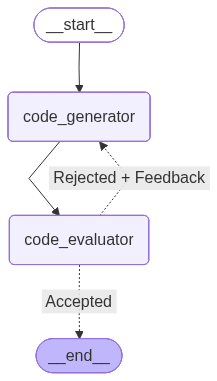

In [26]:
class State(TypedDict):
    code: str
    instruction: str
    feedback: str
    optimized: str

class Feedback(BaseModel):
    grade: Literal["optimized", "not optimized"] = Field(description="코드가 최적화되었는지 판단합니다.")
    feedback: str = Field(description="코드의 개선이 필요하다면, 어떤 부분을 개선할 수 있을지 설명합니다.")

evaluator = llm.with_structured_output(Feedback)

def code_generator(state: State):
    # 코드를 생성하고, 피드백에 따라 리팩토링합니다.

    if state.get("feedback"):
        # 피드백이 있으면

        result = llm.invoke(
            f"""다음 문제를 해결하는 파이썬 코드를 작성하세요. 설명 없이 코드만 출력하세요.
Instruction:{state['instruction']}
다음의 피드백을 고려하세요.
Feedback: {state['feedback']}""")
    else:
        result = llm.invoke(f"""다음 문제를 해결하는 파이썬 코드를 작성하세요. 설명 없이 코드만 출력하세요.
Instruction:{state['instruction']}""")

    return {"code": result.content}


def code_evaluator(state: State):
    # 실제로는 유닛 테스트를 생성해서 검증하는 것도 필요하겠습니다.

    result = evaluator.invoke(f"""다음의 문제를 해결하는 파이썬 코드가 최적화되었는지 한국어로 평가하세요.
평가 기준은 코드의 길이와 실행 속도 및 메모리 효율성입니다.
코드의 길이가 제일 중요합니다.
---
Instruction:{state['instruction']}
---
Source Code: {state['code']}""")

    return {"optimized": result.grade, "feedback": result.feedback}


# Optimized 값에 따라 경로 설정
def route_code(state: State):
    return 'Accepted' if state["optimized"] == "optimized" else 'Rejected + Feedback'


builder = StateGraph(State)

builder.add_node("code_generator", code_generator)
builder.add_node("code_evaluator", code_evaluator)

builder.add_edge(START, "code_generator")
builder.add_edge("code_generator", "code_evaluator")

builder.add_conditional_edges("code_evaluator",route_code,
                              {"Accepted": END,"Rejected + Feedback": "code_generator"})

graph = builder.compile()
graph

In [27]:
for data in graph.stream({'instruction':'자연수보다 작은 소수 개수 구하기'}, stream_mode='updates'):
    if 'code_generator' in data:
        print(data['code_generator']['code'])
    else:
        print(data['code_evaluator']['optimized'],'-->', data['code_evaluator']['feedback'])
    print('--------------')

```python
def count_primes_less_than_n(n):
    if n <= 2:
        return 0

    is_prime = [True] * n
    is_prime[0] = is_prime[1] = False
    count = 0

    for p in range(2, n):
        if is_prime[p]:
            count += 1
            for multiple in range(p * p, n, p):
                is_prime[multiple] = False
    return count

if __name__ == '__main__':
    # 예시 사용법:
    # 10보다 작은 소수의 개수 (2, 3, 5, 7)
    # print(count_primes_less_than_n(10)) # 출력: 4

    # 20보다 작은 소수의 개수 (2, 3, 5, 7, 11, 13, 17, 19)
    # print(count_primes_less_than_n(20)) # 출력: 8
    pass
```
--------------
optimized --> 제공된 코드는 자연수 n보다 작은 소수의 개수를 효율적으로 계산하기 위해 에라토스테네스의 체(Sieve of Eratosthenes) 알고리즘을 사용하고 있습니다. 이 알고리즘은 소수를 찾는 데 있어 매우 최적화된 방법으로, 실행 속도와 메모리 효율성 측면에서 뛰어납니다. 코드 길이 또한 알고리즘의 복잡성을 고려할 때 간결하고 명확하게 작성되어 최적화되었다고 판단됩니다.
--------------


In [28]:
for data in graph.stream({'instruction':'자연수 소인수분해'}, stream_mode='updates'):
    if 'code_generator' in data:
        print(data['code_generator']['code'])
    else:
        print(data['code_evaluator']['optimized'],'-->', data['code_evaluator']['feedback'])
    print('--------------')

```python
def prime_factorization(n):
    if n < 1:
        raise ValueError("자연수(1 이상의 정수)만 소인수분해할 수 있습니다.")
    if n == 1:
        return []

    factors = []
    d = 2
    temp_n = n

    while d * d <= temp_n:
        while temp_n % d == 0:
            factors.append(d)
            temp_n //= d
        d += 1

    if temp_n > 1:
        factors.append(temp_n)

    return factors

if __name__ == '__main__':
    # 예시 사용법 (출력에는 포함되지 않음)
    # print(prime_factorization(12))  # [2, 2, 3]
    # print(prime_factorization(7))   # [7]
    # print(prime_factorization(1))   # []
    # print(prime_factorization(100)) # [2, 2, 5, 5]
    # print(prime_factorization(999)) # [3, 3, 3, 37]
    # print(prime_factorization(2 * 3 * 5 * 7 * 11 * 13)) # [2, 3, 5, 7, 11, 13]
    pass
```
--------------
optimized --> 제공된 소인수분해 코드는 간결하고 효율적으로 작성되었습니다. 코드 길이면에서 더 짧게 만드는 것은 가독성이나 견고함을 해칠 수 있으며, 현재의 코드는 자연수 소인수분해를 수행하는 일반적인 알고리즘(시행 나눗셈, trial division)을 잘 구현하고 있습니다. 실행 속도 측면에서는 제곱근까지 확인하는 방식으로 불필요한 연산을 줄였고, 메

In [29]:
for data in graph.stream({'instruction':'Convex Hull 문제'}, stream_mode='updates'):
    if 'code_generator' in data:
        print(data['code_generator']['code'])
    else:
        print(data['code_evaluator']['optimized'],'-->', data['code_evaluator']['feedback'])
    print('--------------')

```python
def solve_convex_hull(points):
    """
    Computes the convex hull of a set of 2D points using the Monotone Chain algorithm (Andrew's algorithm).

    Args:
        points: A list of (x, y) tuples representing the points.

    Returns:
        A list of (x, y) tuples representing the points on the convex hull,
        ordered counter-clockwise, starting from the leftmost point.
        The returned list does not contain duplicate start/end points.
    """

    if len(points) <= 2:
        return sorted(list(set(points))) # Handle cases with 0, 1, or 2 points, remove duplicates

    # Sort the points lexicographically (by x-coordinate, then by y-coordinate)
    points = sorted(list(set(points))) # Remove duplicates and sort

    # Function to determine the orientation of three points (p, q, r)
    # Returns:
    #   > 0 if p, q, r are in counter-clockwise order
    #   < 0 if p, q, r are in clockwise order
    #   = 0 if p, q, r are collinear
    def cross_product(p, q, r):
 